In [44]:
import pandas as pd

df_gdp = pd.read_csv('sweden_gdp_monthly.csv', sep=None, engine='python')
df_interest = pd.read_csv('sweden_interest_rate_monthly.csv', sep=None, engine='python')
df_unemployment = pd.read_csv('sweden_unemployment_monthly.csv', sep=None, engine='python')

def clean_dataframe(df, date_col_idx, value_col_idx):
    # Remove BOM character from column names
    df.columns = df.columns.str.replace('\ufeff', '', regex=False)

    # Get the actual (cleaned) column names using their indices
    current_date_col_name = df.columns[date_col_idx]
    current_value_col_name = df.columns[value_col_idx]

    # Convert date column to datetime objects, coercing errors
    df[current_date_col_name] = pd.to_datetime(df[current_date_col_name], format='%Y-%m', errors='coerce')

    # Convert value column to numeric, handling comma as decimal separator
    if df[current_value_col_name].dtype == 'object':
        df[current_value_col_name] = df[current_value_col_name].astype(str).str.replace(',', '.', regex=False)
        df[current_value_col_name] = pd.to_numeric(df[current_value_col_name], errors='coerce')

    return df

# Clean df_gdp and rename columns
df_gdp_cleaned = clean_dataframe(df_gdp.copy(), 0, 1) # Pass indices 0 and 1
df_gdp_cleaned = df_gdp_cleaned.rename(columns={df_gdp_cleaned.columns[0]: 'Date', df_gdp_cleaned.columns[1]: 'GDP_Growth'})
df_gdp_cleaned = df_gdp_cleaned.dropna(subset=['Date', 'GDP_Growth'])

# Clean df_interest and rename columns
df_interest_cleaned = clean_dataframe(df_interest.copy(), 0, 1) # Pass indices 0 and 1
df_interest_cleaned = df_interest_cleaned.rename(columns={df_interest_cleaned.columns[0]: 'Date', df_interest_cleaned.columns[1]: 'Interest_Rate'})

# Clean df_unemployment and rename columns
df_unemployment_cleaned = clean_dataframe(df_unemployment.copy(), 0, 1) # Pass indices 0 and 1
df_unemployment_cleaned = df_unemployment_cleaned.rename(columns={df_unemployment_cleaned.columns[0]: 'Date', df_unemployment_cleaned.columns[1]: 'Unemployment_Rate'})

print("Cleaned df_gdp head:")
print(df_gdp_cleaned.head())
print("\nCleaned df_interest head:")
print(df_interest_cleaned.head())
print("\nCleaned df_unemployment head:")
print(df_unemployment_cleaned.head())

Cleaned df_gdp head:
        Date  GDP_Growth
1 2000-02-01         1.8
2 2000-03-01         0.5
3 2000-04-01         0.0
4 2000-05-01         2.8
5 2000-06-01         0.5

Cleaned df_interest head:
        Date  Interest_Rate
0 1990-01-01           11.4
1 1990-02-01           13.0
2 1990-03-01           13.5
3 1990-04-01           12.9
4 1990-05-01           12.0

Cleaned df_unemployment head:
        Date  Unemployment_Rate
0 1983-01-01                3.4
1 1983-02-01                3.7
2 1983-03-01                3.7
3 1983-04-01                3.4
4 1983-05-01                3.7


In [45]:
df_merged = df_gdp_cleaned.merge(df_interest_cleaned, on='Date', how='outer').merge(df_unemployment_cleaned, on='Date', how='outer')
display(df_merged.head())

,Date,GDP_Growth,Interest_Rate,Unemployment_Rate
0,1983-01-01,NaN,NaN,3.4
1,1983-02-01,NaN,NaN,3.7
2,1983-03-01,NaN,NaN,3.7
3,1983-04-01,NaN,NaN,3.4
4,1983-05-01,NaN,NaN,3.7


In [46]:
numerical_cols = ['GDP_Growth', 'Interest_Rate', 'Unemployment_Rate']
covariance_matrix = df_merged[numerical_cols].cov()
print("Covariance Matrix:")
print(covariance_matrix)

Covariance Matrix:
                   GDP_Growth  Interest_Rate  Unemployment_Rate
GDP_Growth           1.702954      -0.084034           0.041250
Interest_Rate       -0.084034      26.399865          -2.749306
Unemployment_Rate    0.041250      -2.749306           5.631566


In [47]:
mean_vector = df_merged[numerical_cols].mean()
print("Mean Vector:")
print(mean_vector)

Mean Vector:
GDP_Growth           0.169775
Interest_Rate        3.521940
Unemployment_Rate    6.583915
dtype: float64


In [48]:
from scipy.stats import multivariate_normal
mvn = multivariate_normal(mean=mean_vector, cov=covariance_matrix)


In [49]:
# Cell removed - visualization not needed for this analysis

In [50]:
df_pds = pd.read_csv('pdsFitchData.csv')

# Remove BOM character from column names
df_pds.columns = df_pds.columns.str.replace('\ufeff', '', regex=False)

# Convert 'Date' column to datetime with YYYY-MM format (matches macro data format)
if 'Date' in df_pds.columns:
    df_pds['Date'] = pd.to_datetime(df_pds['Date'], format='%Y-%m')
else:
    # Fallback: if no 'Date' column, use the first column
    date_col_name = df_pds.columns[0]
    df_pds[date_col_name] = pd.to_datetime(df_pds[date_col_name], format='%Y-%m')
    df_pds = df_pds.rename(columns={date_col_name: 'Date'})

# Keep only the 12_month PD column and drop other timeframes since they're empty
df_pds = df_pds[['Company_number', 'Date', '12_month', 'Sector']]

# Add PDzero column: the first PD reading for each company
# Sort by Date to ensure we get the earliest reading
df_pds = df_pds.sort_values(['Company_number', 'Date'])
# Get the first PD value for each company
first_pd = df_pds.groupby('Company_number')['12_month'].first()
# Map it back to all rows for each company
df_pds['PDzero'] = df_pds['Company_number'].map(first_pd)

print("Columns in df_pds:", df_pds.columns.tolist())
print("\nFirst few rows of df_pds:")
display(df_pds.head())

print("\nBefore merge - PD data shape:", df_pds.shape)
print("Before merge - Macro data shape:", df_merged.shape)
print(f"Non-null Sector values: {df_pds['Sector'].notna().sum()} ({100*df_pds['Sector'].notna().sum()/len(df_pds):.1f}%)")

Columns in df_pds: ['Company_number', 'Date', '12_month', 'Sector', 'PDzero']

First few rows of df_pds:


,Company_number,Date,12_month,Sector,PDzero
40854,80091583.0,2012-07-01,0.0012,Transportation & Logistics,0.0012
40855,80091583.0,2015-04-01,0.0012,Transportation & Logistics,0.0012
23177,80091774.0,2012-07-01,0.0012,Energy & Resources,0.0012
23178,80091774.0,2012-07-01,0.0012,Energy & Resources,0.0012
23179,80091774.0,2012-07-01,0.0005,Energy & Resources,0.0012



Before merge - PD data shape: (84585, 5)
Before merge - Macro data shape: (517, 4)
Non-null Sector values: 72119 (85.3%)


# Task
To proceed with the plan, the next step is to merge the `df_pds` DataFrame, which contains company Probability of Defaults (PDs), with the `df_merged` DataFrame, which contains macroeconomic indicators (GDP_Growth, Interest_Rate, and Unemployment_Rate). This merge will be performed on the 'Date' column to combine these datasets.

After merging, we will inspect the resulting DataFrame to ensure the merge was successful and to understand the combined data structure. This will lay the foundation for identifying key variables and performing the sensitivity analysis.

To achieve this, I will perform the following actions:
1. Merge `df_pds` and `df_merged` on the 'Date' column using an inner join to ensure that only dates present in both DataFrames are included.
2. Display the head of the newly merged DataFrame (`df_final`).
3. Print the shape and information of `df_final` to verify the merge and check data types and non-null counts.

## Merge PDs Data with Macroeconomic Data

### Subtask:
Merge the prepared `df_pds` DataFrame with the `df_merged` DataFrame on the 'Date' column to combine company PDs with macroeconomic indicators. Then, inspect the resulting merged DataFrame.


**Reasoning**:
To merge the two DataFrames as instructed, I will perform an inner join on the 'Date' column between `df_pds` and `df_merged` and store the result in `df_final`. Afterwards, I will display the head, shape, and info of the merged DataFrame to inspect its structure and content.



In [51]:
# Merge PDs with macroeconomic data
# Both datasets now have YYYY-MM date format and will merge properly
df_final = pd.merge(df_pds, df_merged, on='Date', how='inner')

print("\nAfter merge - Final data shape:", df_final.shape)
print(f"Retained {df_final.shape[0]} out of {df_pds.shape[0]} PD datapoints ({100*df_final.shape[0]/df_pds.shape[0]:.1f}%)")

print("\nFirst few rows of the merged DataFrame (df_final):")
display(df_final.head())

print("\nShape of df_final:")
print(df_final.shape)

print("\nInfo of df_final:")
df_final.info()


After merge - Final data shape: (84585, 8)
Retained 84585 out of 84585 PD datapoints (100.0%)

First few rows of the merged DataFrame (df_final):


,Company_number,Date,12_month,Sector,PDzero,GDP_Growth,Interest_Rate,Unemployment_Rate
0,80091583.0,2012-07-01,0.0012,Transportation & Logistics,0.0012,-0.8,1.5,8.1
1,80091583.0,2015-04-01,0.0012,Transportation & Logistics,0.0012,1.5,-0.3,7.9
2,80091774.0,2012-07-01,0.0012,Energy & Resources,0.0012,-0.8,1.5,8.1
3,80091774.0,2012-07-01,0.0012,Energy & Resources,0.0012,-0.8,1.5,8.1
4,80091774.0,2012-07-01,0.0005,Energy & Resources,0.0012,-0.8,1.5,8.1



Shape of df_final:
(84585, 8)

Info of df_final:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84585 entries, 0 to 84584
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Company_number     72119 non-null  float64       
 1   Date               84585 non-null  datetime64[ns]
 2   12_month           84585 non-null  float64       
 3   Sector             72119 non-null  object        
 4   PDzero             72119 non-null  float64       
 5   GDP_Growth         84585 non-null  float64       
 6   Interest_Rate      84585 non-null  float64       
 7   Unemployment_Rate  84585 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 5.2+ MB


**Reasoning**:
The previous step successfully merged the dataframes. Before proceeding with the sensitivity analysis using linear regression, it is crucial to handle missing values, particularly in the macroeconomic indicators as indicated by the `df_final.info()` output for 'GDP_Growth'. Removing rows with NaN values in the macroeconomic columns will ensure that the subsequent regression analysis is performed on complete data, preventing errors and ensuring valid results.



In [52]:
macro_cols = ['GDP_Growth', 'Interest_Rate', 'Unemployment_Rate']
# Drop rows with NaN in macro columns AND Sector column (needed for sector analysis)
df_final_cleaned = df_final.dropna(subset=macro_cols + ['Sector']).copy()

print("Shape of df_final before dropping NaNs:", df_final.shape)
print("Shape of df_final after dropping NaNs (macro + Sector):", df_final_cleaned.shape)
print(f"Retained {100*df_final_cleaned.shape[0]/df_final.shape[0]:.1f}% of observations")
print(f"Number of unique sectors: {df_final_cleaned['Sector'].nunique()}")
print("\nInfo of df_final_cleaned after handling NaNs:")
df_final_cleaned.info()

Shape of df_final before dropping NaNs: (84585, 8)
Shape of df_final after dropping NaNs (macro + Sector): (72119, 8)
Retained 85.3% of observations
Number of unique sectors: 15

Info of df_final_cleaned after handling NaNs:
<class 'pandas.core.frame.DataFrame'>
Index: 72119 entries, 0 to 72118
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Company_number     72119 non-null  float64       
 1   Date               72119 non-null  datetime64[ns]
 2   12_month           72119 non-null  float64       
 3   Sector             72119 non-null  object        
 4   PDzero             72119 non-null  float64       
 5   GDP_Growth         72119 non-null  float64       
 6   Interest_Rate      72119 non-null  float64       
 7   Unemployment_Rate  72119 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 5.0+ MB


**Reasoning**:
To prepare for the sensitivity analysis, I will explicitly define the dependent variables (PD maturity columns), independent variables (macroeconomic indicators), and the categorical variable (sector column) based on the task description and the current state of `df_final_cleaned`. This clear identification is essential for setting up the linear regression models correctly.



In [53]:
pd_maturity_cols = ['12_month']  # Only focus on 12-month PD
macro_cols = ['GDP_Growth', 'Interest_Rate', 'Unemployment_Rate']
sector_col = 'Sector'

print("Dependent variables (PD Maturity Columns):", pd_maturity_cols)
print("Independent variables (Macroeconomic Indicators):", macro_cols)
print("Categorical variable (Sector Column):", sector_col)

Dependent variables (PD Maturity Columns): ['12_month']
Independent variables (Macroeconomic Indicators): ['GDP_Growth', 'Interest_Rate', 'Unemployment_Rate']
Categorical variable (Sector Column): Sector


**Reasoning**:
To calculate the sensitivity of each PD maturity to macroeconomic factors for each sector, I will iterate through each unique sector and each PD maturity column. For each combination, I will perform a linear regression using `statsmodels.formula.api.ols` to model the PD maturity as a function of the macroeconomic indicators, storing the regression coefficients (sensitivities) in a list. Finally, I will convert this list into a structured DataFrame for easy analysis.



In [54]:
import statsmodels.api as sm
import numpy as np

def calculate_logit(p):
    """
    Computes the log-odds (logit) of a probability.
    Clips values to avoid log(0) or division by zero.
    """
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return np.log(p / (1 - p))


sensitivities_data = []

for sector in df_final_cleaned[sector_col].unique():
    sector_df = df_final_cleaned[df_final_cleaned[sector_col] == sector].copy()
    
    print(f"\nProcessing sector: {sector} (n={len(sector_df)})")

    for pd_col in pd_maturity_cols:
        #pdzero_col = f'{pd_col}_t1'  # Lagged PD column (t-1)
        pdzero_col = 'PDzero'
        
        try:
            # Step 1: Transform the Data - Calculate the 'Change in Logit'
            sector_df['logit_pd'] = calculate_logit(sector_df[pd_col])
            sector_df['logit_pd_zero'] = calculate_logit(sector_df[pdzero_col])
            
            # This delta is what the Macro factors actually explain
            sector_df['delta_logit'] = sector_df['logit_pd'] - sector_df['logit_pd_zero']
            
            # Step 2: Prepare Regression Variables
            y = sector_df['delta_logit']
            X = sector_df[macro_cols]
            
            # Add a constant (intercept) to capture any systematic trend
            X = sm.add_constant(X)
            
            # Drop any remaining NaN values
            valid_idx = ~(y.isna() | X.isna().any(axis=1))
            y = y[valid_idx]
            X = X[valid_idx]
            
            if len(y) < 10:  # Need minimum observations
                print(f"  Skipping {pd_col}: insufficient data (n={len(y)})")
                continue
            
            # Step 3: Run the OLS Regression
            model = sm.OLS(y, X).fit()
            
            # Step 4: Store the Sensitivities
            result = {
                'Sector': sector,
                'PD_Horizon': pd_col,
                'Intercept': model.params['const'],
                'N_observations': len(y),
                'R_squared': model.rsquared
            }
            
            # Add sensitivities for each macroeconomic variable
            for col in macro_cols:
                result[col] = model.params[col]
            
            sensitivities_data.append(result)
            print(f"  ✓ {pd_col}: R²={model.rsquared:.3f}, N={len(y)}")

        except Exception as e:
            print(f"  ✗ Could not fit model for {pd_col}: {e}")

df_sensitivities = pd.DataFrame(sensitivities_data)
print("\n" + "="*80)
print("SENSITIVITY ANALYSIS RESULTS")
print("="*80)
display(df_sensitivities)


Processing sector: Transportation & Logistics (n=2934)
  ✓ 12_month: R²=0.008, N=2934

Processing sector: Energy & Resources (n=20212)
  ✓ 12_month: R²=0.014, N=20212

Processing sector: Telecommunications & Media (n=7152)
  ✓ 12_month: R²=0.005, N=7152

Processing sector: Financial Services (n=11109)
  ✓ 12_month: R²=0.000, N=11109

Processing sector: Industrial & Manufacturing (n=9534)
  ✓ 12_month: R²=0.037, N=9534

Processing sector: Consumer Goods & Retail (n=8061)
  ✓ 12_month: R²=0.001, N=8061

Processing sector: Professional Services & Consulting (n=1199)
  ✓ 12_month: R²=0.009, N=1199

Processing sector: Technology & Software (n=3717)
  ✓ 12_month: R²=0.003, N=3717

Processing sector: Healthcare & Pharmaceuticals (n=3750)
  ✓ 12_month: R²=0.024, N=3750

Processing sector: Real Estate & Property (n=3291)
  ✓ 12_month: R²=0.023, N=3291

Processing sector: Unassigned (n=685)
  ✓ 12_month: R²=0.122, N=685

Processing sector: Waste Management, Inc. (n=87)
  ✓ 12_month: R²=0.808, N

,Sector,PD_Horizon,Intercept,N_observations,R_squared,GDP_Growth,Interest_Rate,Unemployment_Rate
0,Transportation & Logistics,12_month,1.119814,2934,0.007759,0.059202,-0.022577,-0.098834
1,Energy & Resources,12_month,-0.455229,20212,0.013767,-0.029930,-0.104634,0.102991
2,Telecommunications & Media,12_month,0.793861,7152,0.005175,-0.056227,0.025210,-0.050681
3,Financial Services,12_month,0.728440,11109,0.000456,0.003463,-0.015383,-0.027506
4,Industrial & Manufacturing,12_month,-1.567603,9534,0.037024,-0.032026,-0.105235,0.245348
5,Consumer Goods & Retail,12_month,-0.074254,8061,0.001080,-0.006737,-0.019448,0.052252
6,Professional Services & Consulting,12_month,0.105597,1199,0.009019,0.029880,-0.075137,0.045013
7,Technology & Software,12_month,0.185970,3717,0.002702,0.023892,0.029169,-0.013797
8,Healthcare & Pharmaceuticals,12_month,1.793196,3750,0.024023,-0.006040,0.071694,-0.233176
9,Real Estate & Property,12_month,-0.377503,3291,0.023401,0.025225,0.162632,0.094186


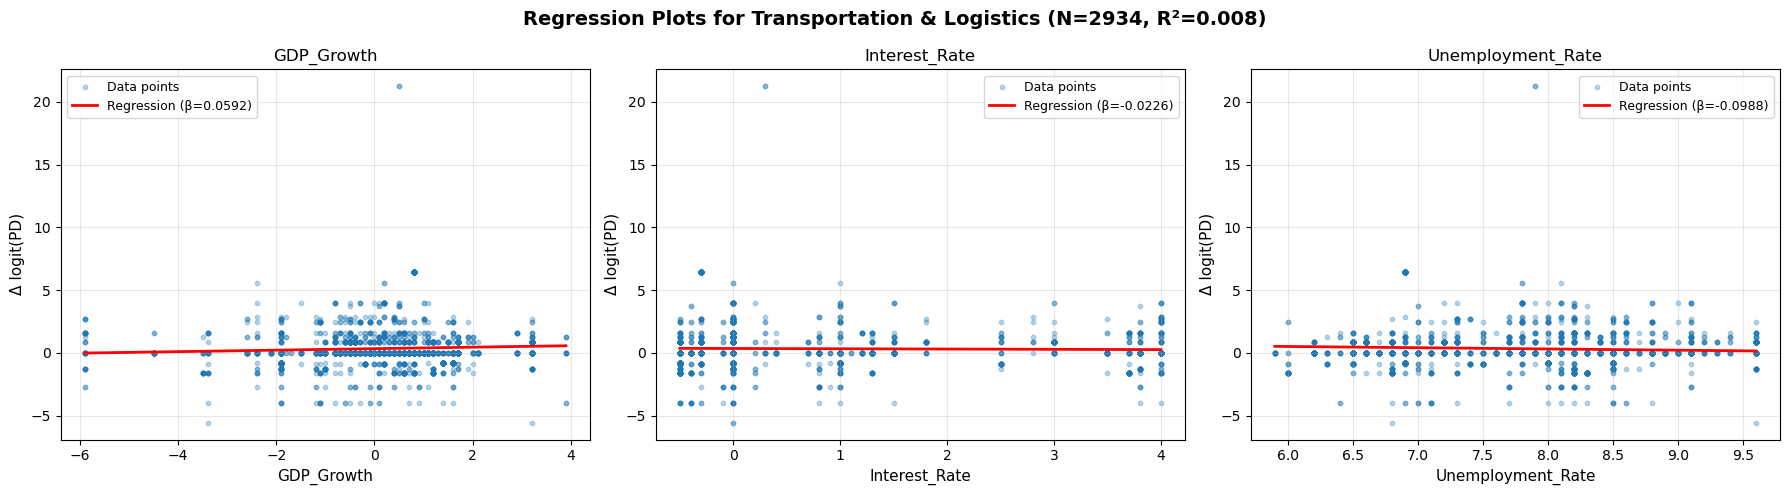


Completed plot for Transportation & Logistics


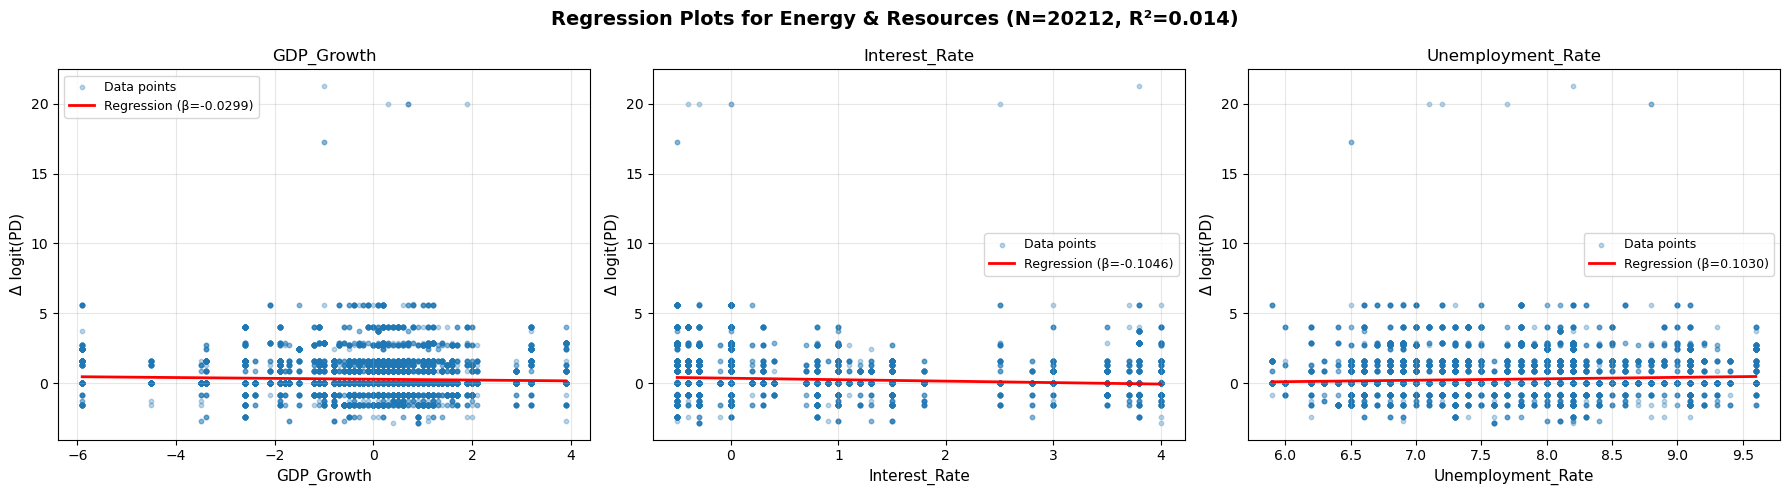


Completed plot for Energy & Resources


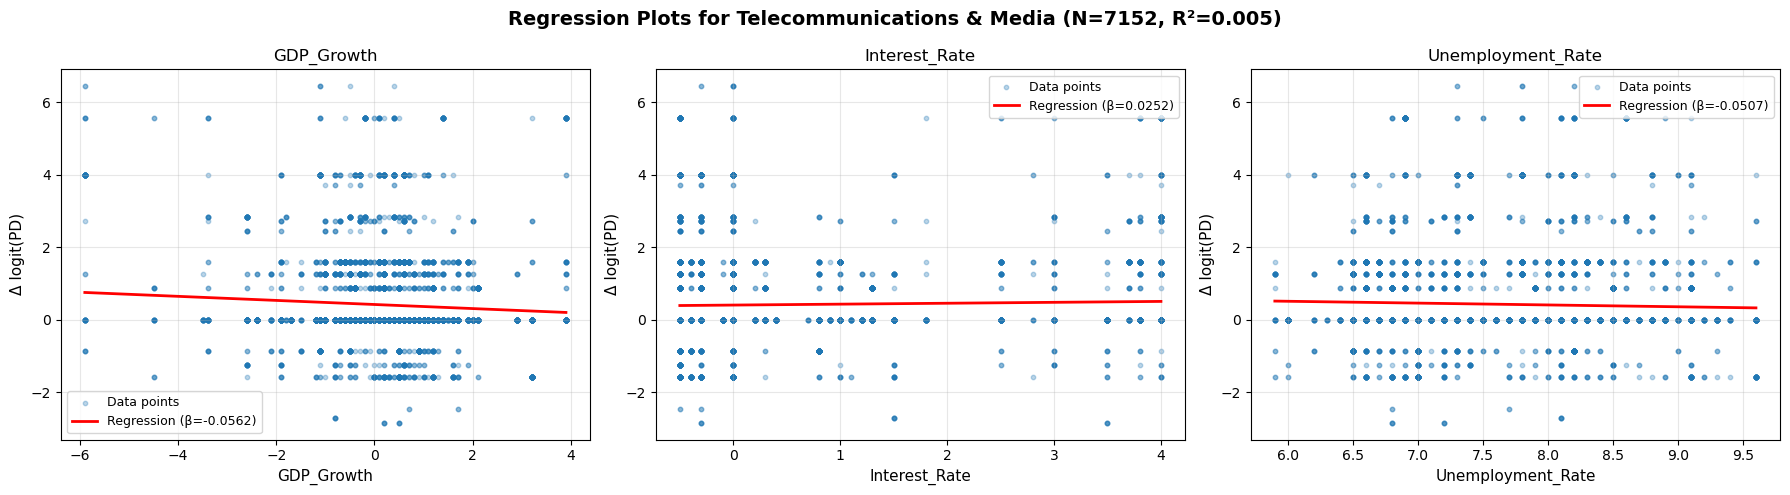


Completed plot for Telecommunications & Media


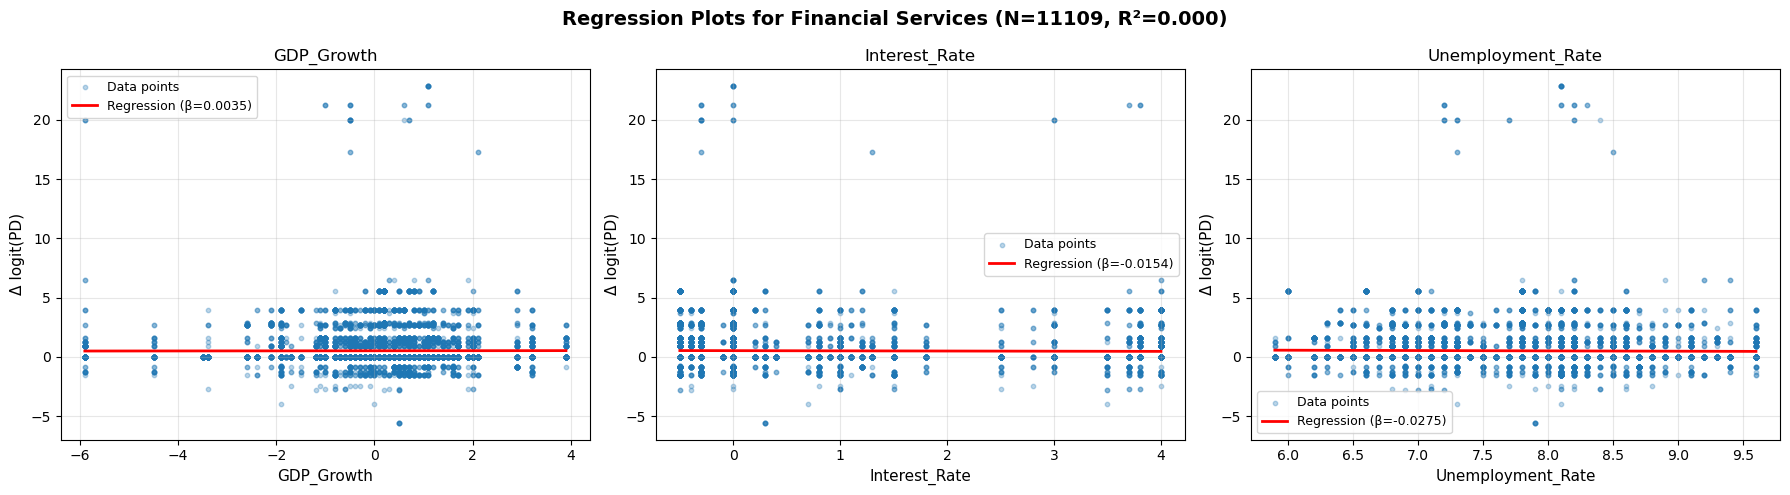


Completed plot for Financial Services


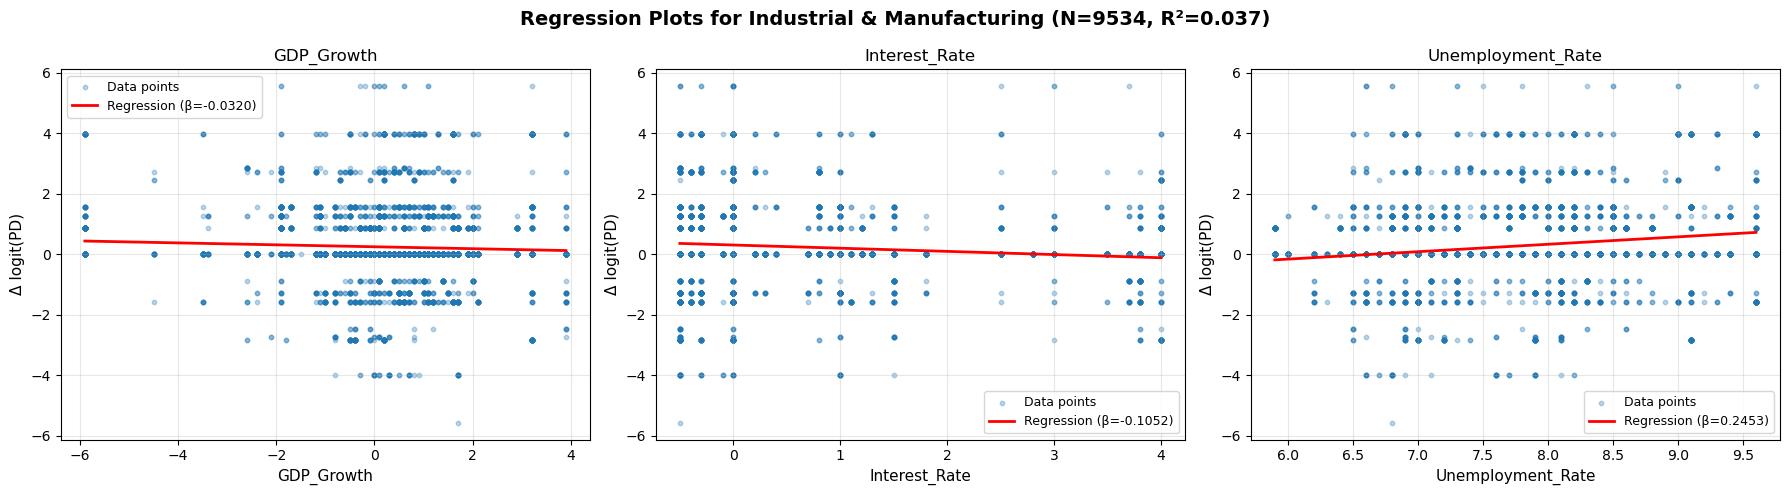


Completed plot for Industrial & Manufacturing


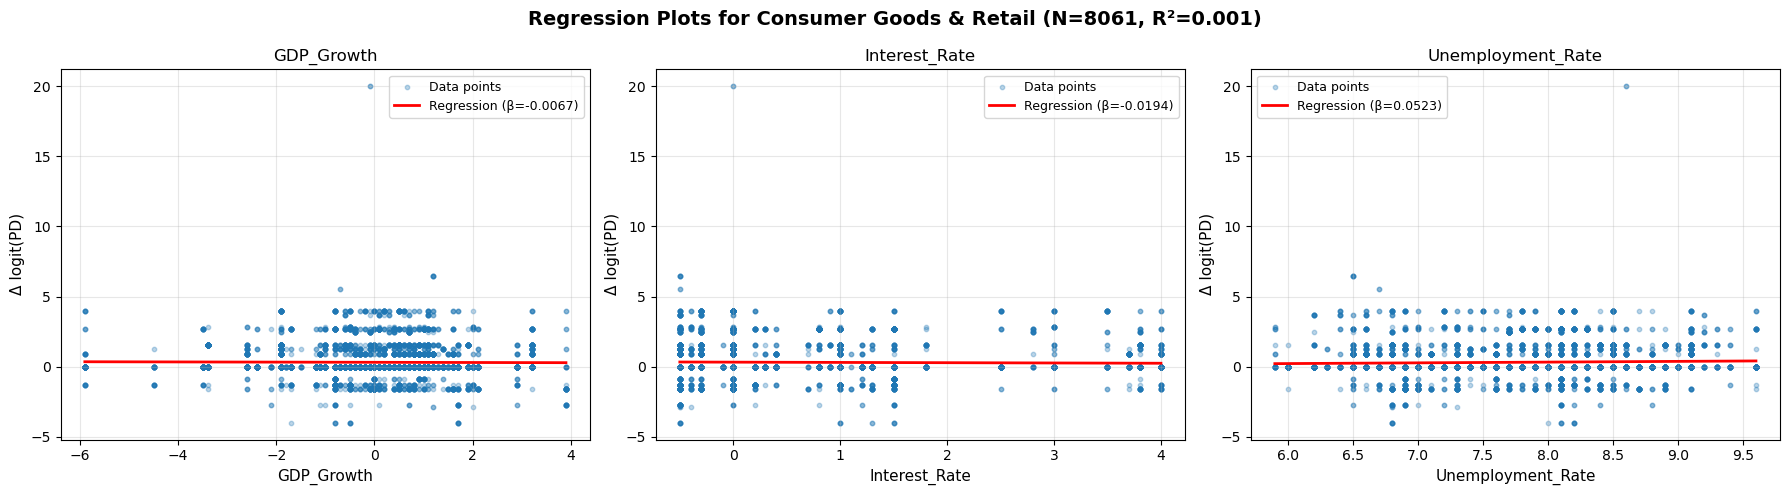


Completed plot for Consumer Goods & Retail


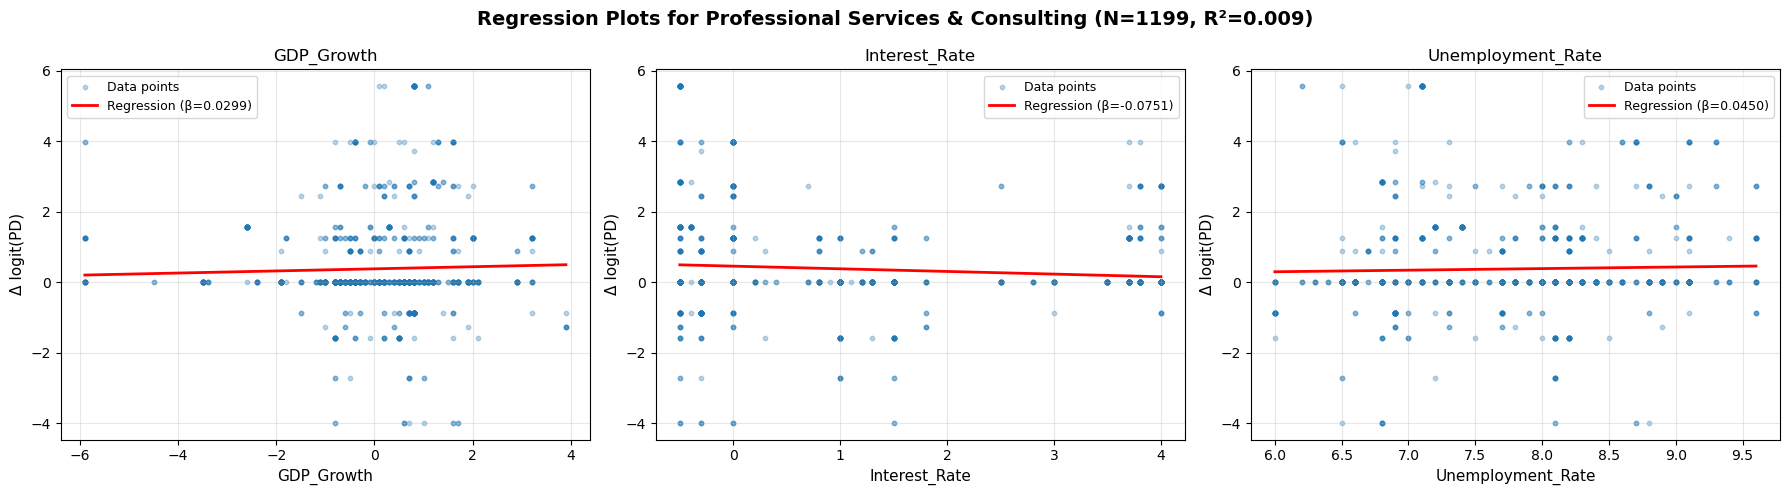


Completed plot for Professional Services & Consulting


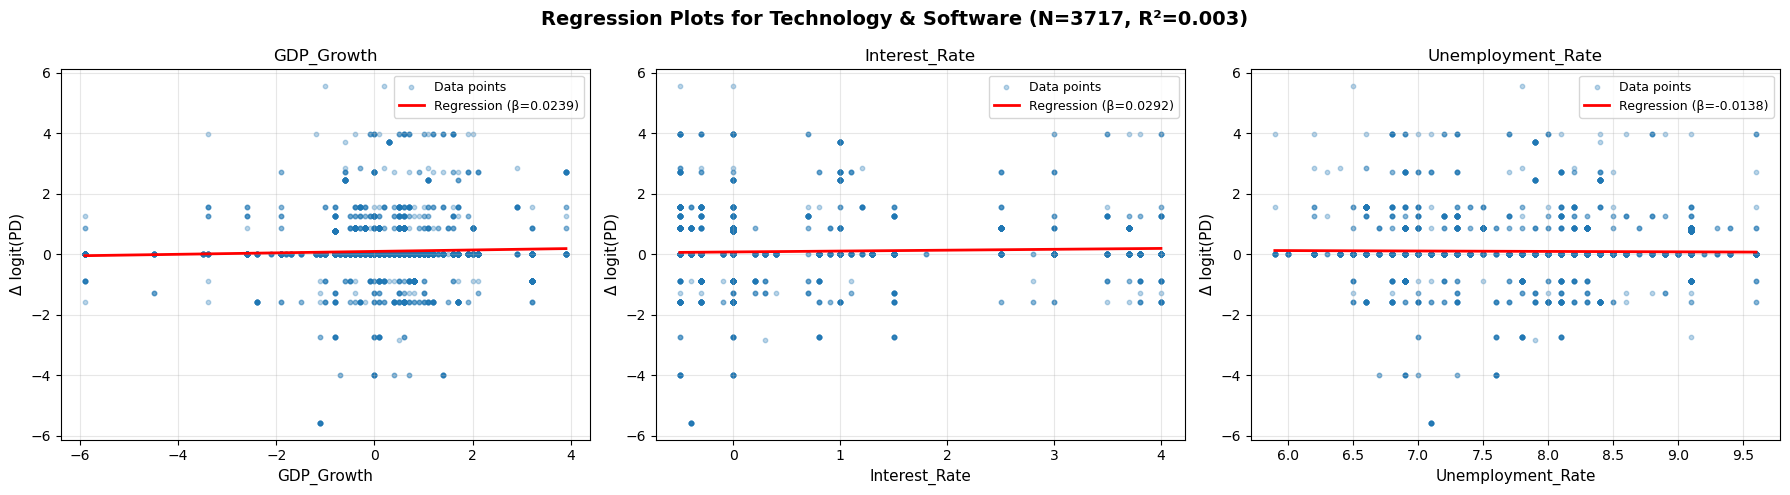


Completed plot for Technology & Software


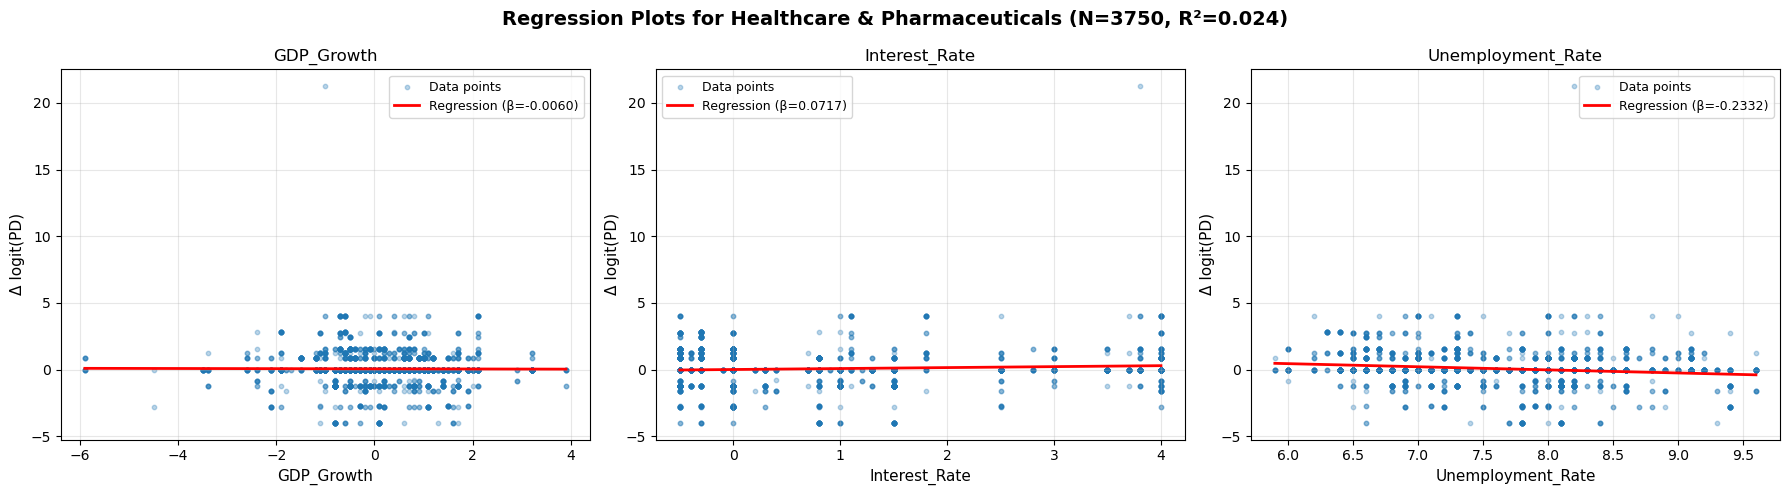


Completed plot for Healthcare & Pharmaceuticals


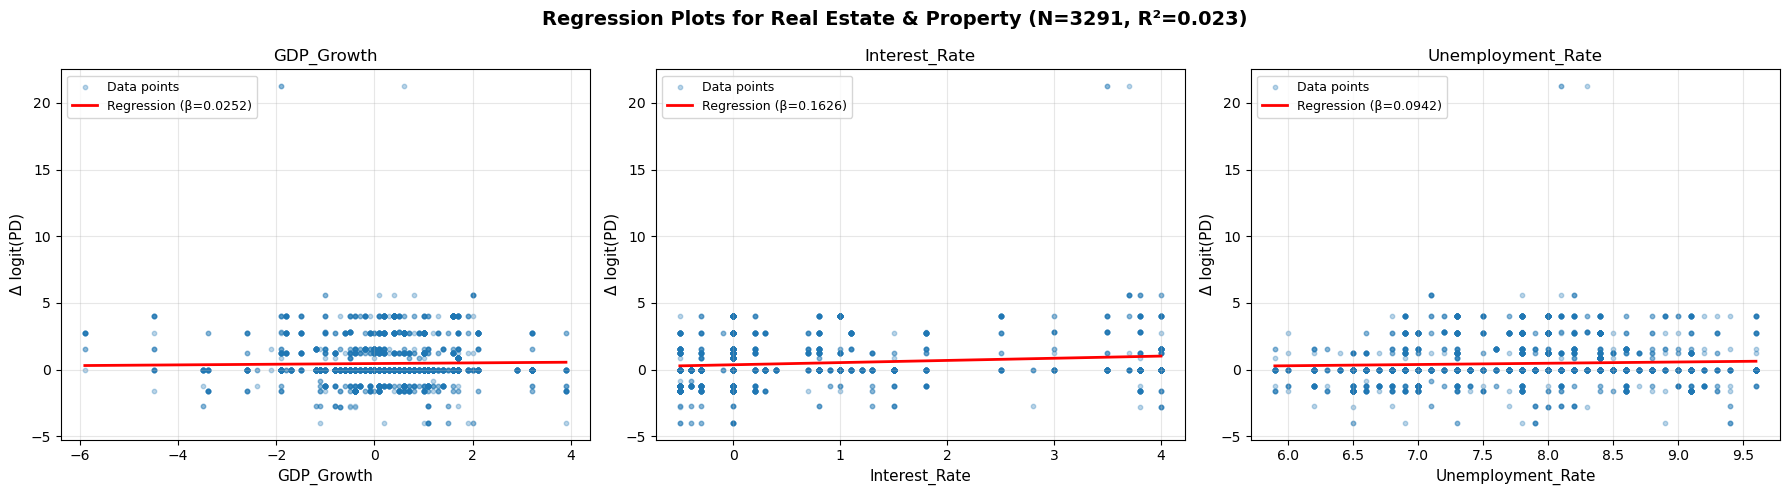


Completed plot for Real Estate & Property


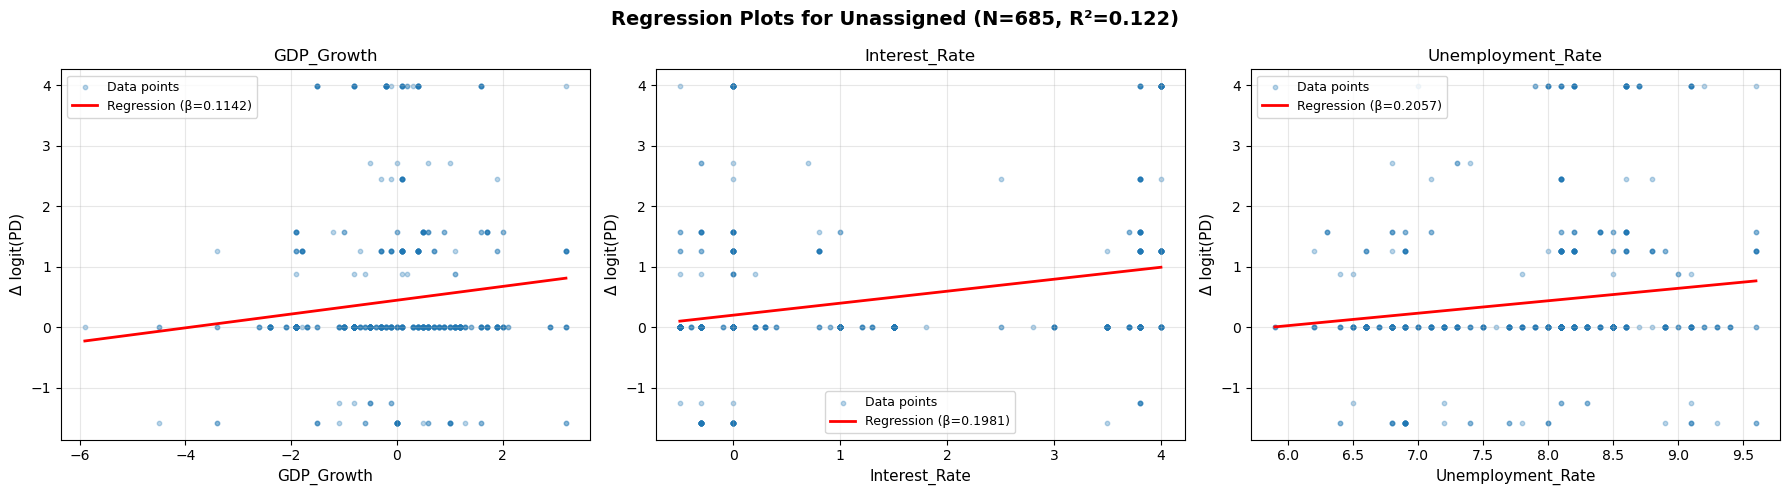


Completed plot for Unassigned


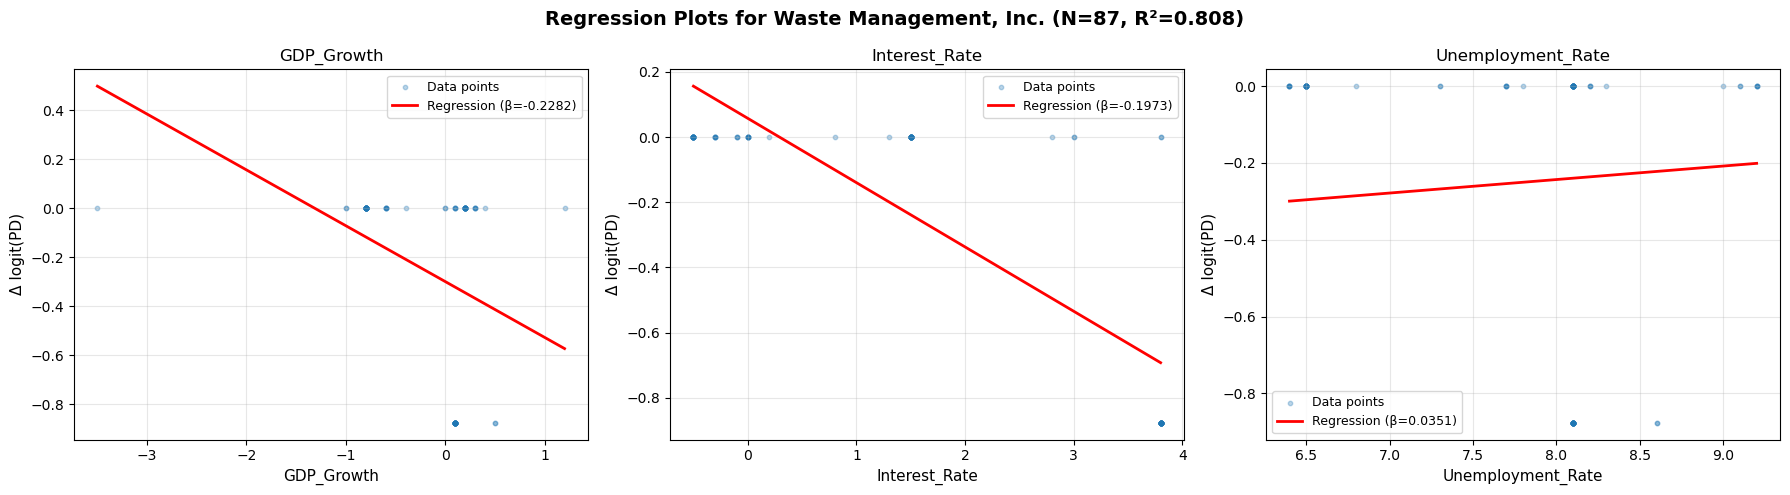


Completed plot for Waste Management, Inc.


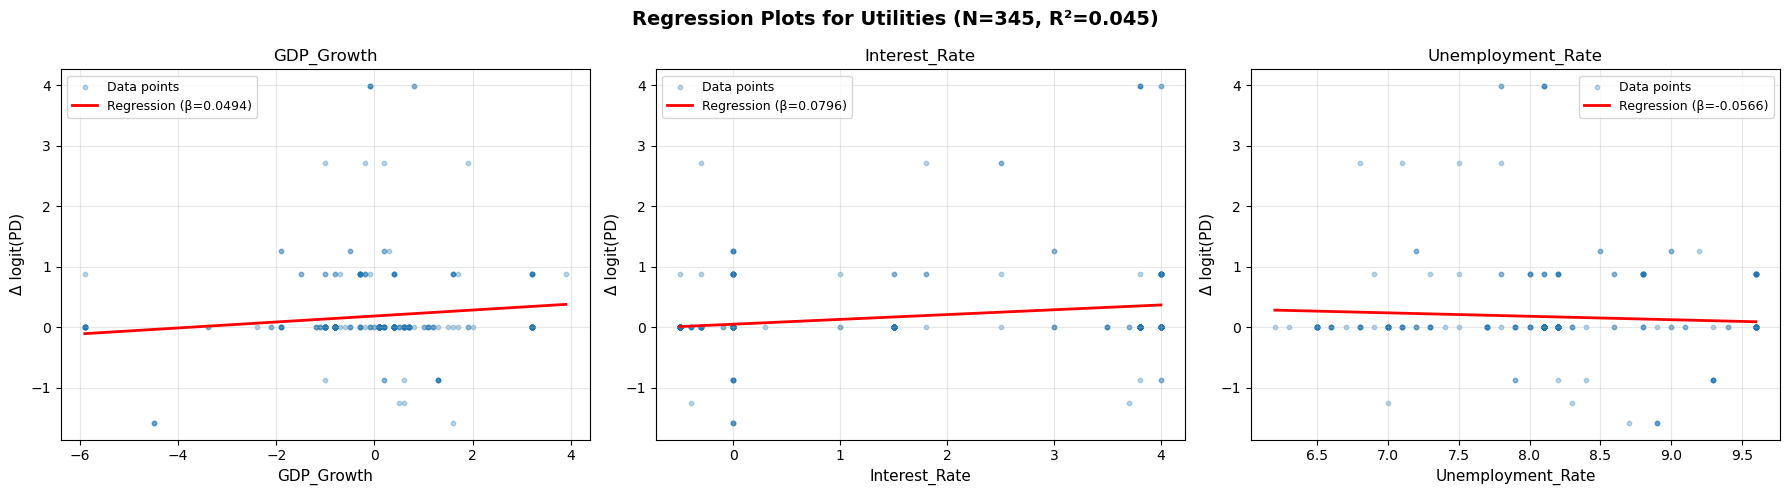


Completed plot for Utilities


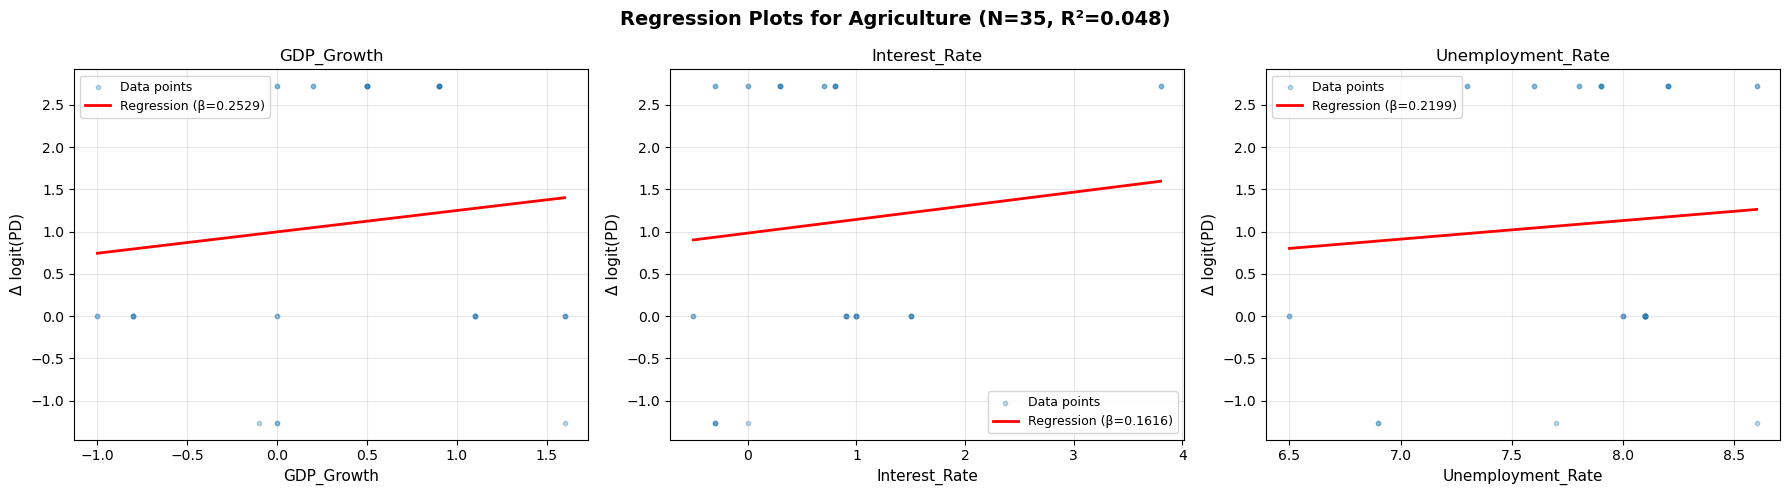


Completed plot for Agriculture


In [55]:
import matplotlib.pyplot as plt

# Create regression plots for each sector
sectors_to_plot = df_sensitivities['Sector'].unique()

for sector in sectors_to_plot:
    # Get the sensitivity coefficients for this sector
    sector_sens = df_sensitivities[df_sensitivities['Sector'] == sector].iloc[0]
    
    # Get the data for this sector
    sector_df = df_final_cleaned[df_final_cleaned[sector_col] == sector].copy()
    sector_df['logit_pd'] = calculate_logit(sector_df['12_month'])
    sector_df['logit_pd_zero'] = calculate_logit(sector_df['PDzero'])
    sector_df['delta_logit'] = sector_df['logit_pd'] - sector_df['logit_pd_zero']
    
    # Create a figure with 3 subplots (one for each macro variable)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Regression Plots for {sector} (N={len(sector_df)}, R²={sector_sens["R_squared"]:.3f})', 
                 fontsize=14, fontweight='bold')
    
    for idx, macro_var in enumerate(macro_cols):
        ax = axes[idx]
        
        # Get the data
        X_data = sector_df[macro_var].values
        y_data = sector_df['delta_logit'].values
        
        # Remove any NaN values
        valid_mask = ~(np.isnan(X_data) | np.isnan(y_data))
        X_data = X_data[valid_mask]
        y_data = y_data[valid_mask]
        
        # Plot scatter points
        ax.scatter(X_data, y_data, alpha=0.3, s=10, label='Data points')
        
        # Calculate regression line
        # For multivariate regression: y = intercept + β1*X1 + β2*X2 + β3*X3
        # To visualize one variable, we hold others at their mean
        intercept = sector_sens['Intercept']
        coef = sector_sens[macro_var]
        
        # Calculate the contribution from other variables at their mean
        other_vars_contribution = 0
        for other_var in macro_cols:
            if other_var != macro_var:
                mean_val = sector_df[other_var].mean()
                other_vars_contribution += sector_sens[other_var] * mean_val
        
        # Create points for the regression line
        X_range = np.linspace(X_data.min(), X_data.max(), 100)
        y_pred = intercept + coef * X_range + other_vars_contribution
        
        # Plot regression line
        ax.plot(X_range, y_pred, 'r-', linewidth=2, 
                label=f'Regression (β={coef:.4f})')
        
        ax.set_xlabel(macro_var, fontsize=11)
        ax.set_ylabel('Δ logit(PD)', fontsize=11)
        ax.set_title(f'{macro_var}', fontsize=12)
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print(f"\nCompleted plot for {sector}")


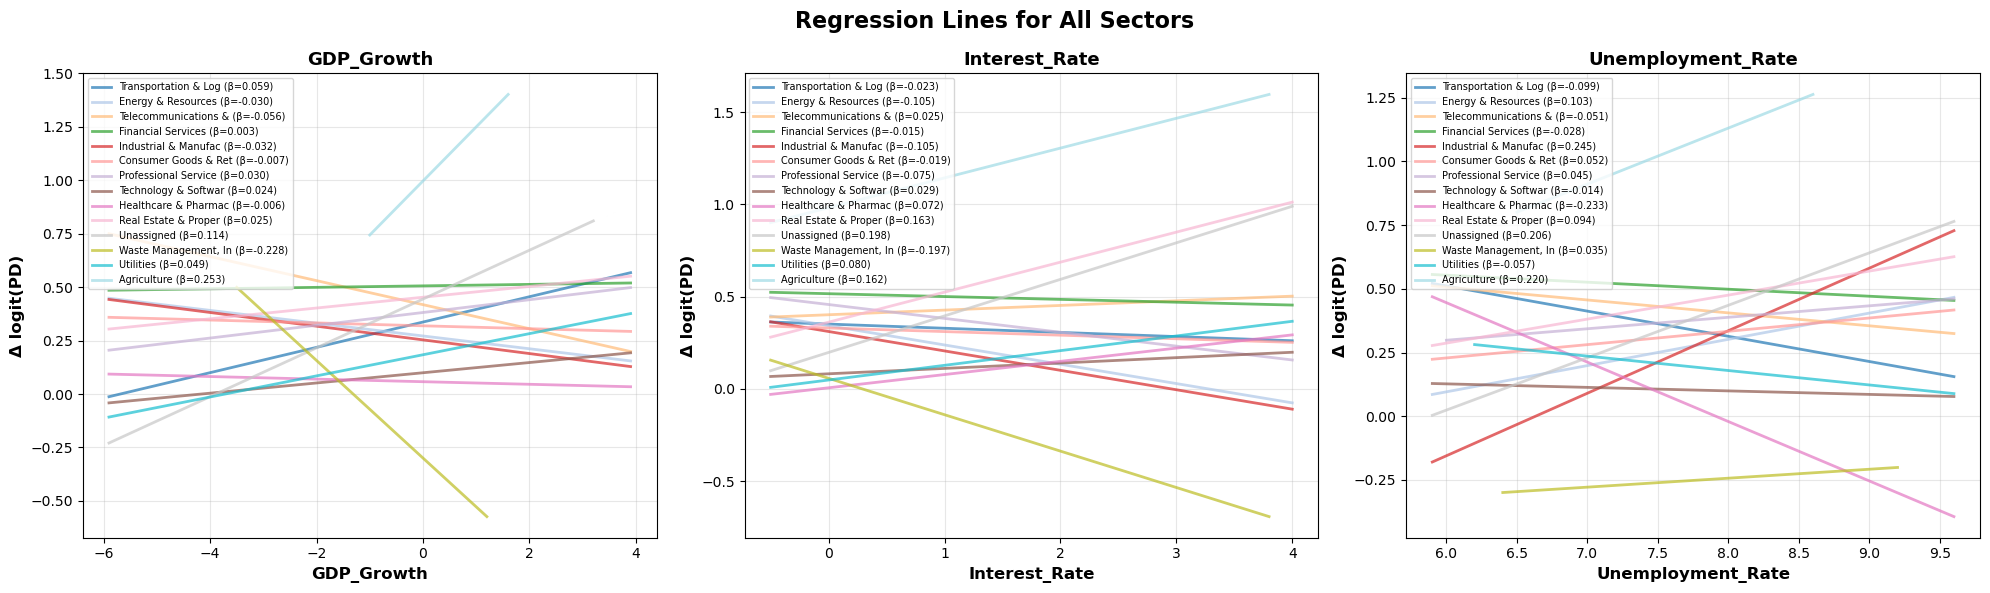


Completed comparison plot for all sectors


In [56]:
# Alternative view: All sectors on same plots for comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Regression Lines for All Sectors', fontsize=16, fontweight='bold')

colors = plt.cm.tab20(np.linspace(0, 1, len(sectors_to_plot)))

for idx, macro_var in enumerate(macro_cols):
    ax = axes[idx]
    
    for sector_idx, sector in enumerate(sectors_to_plot):
        # Get the sensitivity coefficients for this sector
        sector_sens = df_sensitivities[df_sensitivities['Sector'] == sector].iloc[0]
        
        # Get the data for this sector
        sector_df = df_final_cleaned[df_final_cleaned[sector_col] == sector].copy()
        sector_df['logit_pd'] = calculate_logit(sector_df['12_month'])
        sector_df['logit_pd_zero'] = calculate_logit(sector_df['PDzero'])
        sector_df['delta_logit'] = sector_df['logit_pd'] - sector_df['logit_pd_zero']
        
        # Get the data
        X_data = sector_df[macro_var].values
        valid_mask = ~np.isnan(X_data)
        X_data = X_data[valid_mask]
        
        if len(X_data) == 0:
            continue
        
        # Calculate regression line
        intercept = sector_sens['Intercept']
        coef = sector_sens[macro_var]
        
        # Calculate the contribution from other variables at their mean
        other_vars_contribution = 0
        for other_var in macro_cols:
            if other_var != macro_var:
                mean_val = sector_df[other_var].mean()
                other_vars_contribution += sector_sens[other_var] * mean_val
        
        # Create points for the regression line
        X_range = np.linspace(X_data.min(), X_data.max(), 100)
        y_pred = intercept + coef * X_range + other_vars_contribution
        
        # Plot regression line
        ax.plot(X_range, y_pred, linewidth=2, color=colors[sector_idx],
                label=f'{sector[:20]} (β={coef:.3f})', alpha=0.7)
    
    ax.set_xlabel(macro_var, fontsize=12, fontweight='bold')
    ax.set_ylabel('Δ logit(PD)', fontsize=12, fontweight='bold')
    ax.set_title(f'{macro_var}', fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=7, ncol=1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\nCompleted comparison plot for all sectors")

In [57]:
# Export df_final_cleaned to CSV
output_filename = 'df_final_cleaned.csv'
df_final_cleaned.to_csv(output_filename, index=False)
print(f"✓ Successfully exported dataframe to: {output_filename}")
print(f"  - Rows: {df_final_cleaned.shape[0]:,}")
print(f"  - Columns: {df_final_cleaned.shape[1]}")
print(f"  - File size: {df_final_cleaned.memory_usage(deep=True).sum() / 1024**2:.2f} MB (approximate)")

✓ Successfully exported dataframe to: df_final_cleaned.csv
  - Rows: 72,119
  - Columns: 8
  - File size: 9.27 MB (approximate)


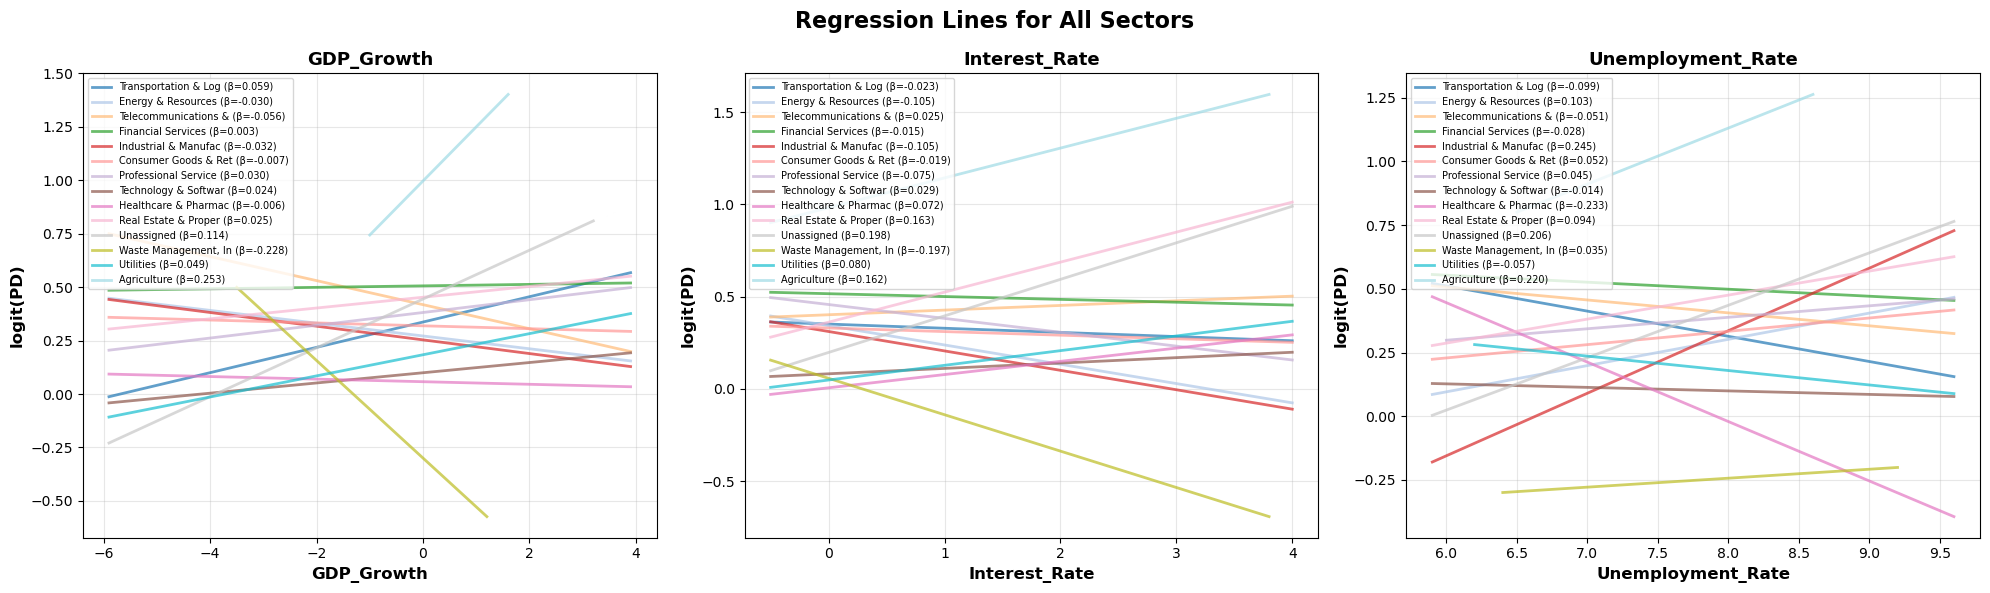


Completed comparison plot for all sectors


In [58]:
# Alternative view: All sectors on same plots for comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Regression Lines for All Sectors', fontsize=16, fontweight='bold')

colors = plt.cm.tab20(np.linspace(0, 1, len(sectors_to_plot)))

for idx, macro_var in enumerate(macro_cols):
    ax = axes[idx]
    
    for sector_idx, sector in enumerate(sectors_to_plot):
        # Get the sensitivity coefficients for this sector
        sector_sens = df_sensitivities[df_sensitivities['Sector'] == sector].iloc[0]
        
        # Get the data for this sector
        sector_df = df_final_cleaned[df_final_cleaned[sector_col] == sector].copy()
        sector_df['logit_pd'] = calculate_logit(sector_df['12_month'])
        
        # Get the data
        X_data = sector_df[macro_var].values
        valid_mask = ~np.isnan(X_data)
        X_data = X_data[valid_mask]
        
        if len(X_data) == 0:
            continue
        
        # Calculate regression line
        intercept = sector_sens['Intercept']
        coef = sector_sens[macro_var]
        
        # Calculate the contribution from other variables at their mean
        other_vars_contribution = 0
        for other_var in macro_cols:
            if other_var != macro_var:
                mean_val = sector_df[other_var].mean()
                other_vars_contribution += sector_sens[other_var] * mean_val
        
        # Create points for the regression line
        X_range = np.linspace(X_data.min(), X_data.max(), 100)
        y_pred = intercept + coef * X_range + other_vars_contribution
        
        # Plot regression line
        ax.plot(X_range, y_pred, linewidth=2, color=colors[sector_idx],
                label=f'{sector[:20]} (β={coef:.3f})', alpha=0.7)
    
    ax.set_xlabel(macro_var, fontsize=12, fontweight='bold')
    ax.set_ylabel('logit(PD)', fontsize=12, fontweight='bold')
    ax.set_title(f'{macro_var}', fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=7, ncol=1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\nCompleted comparison plot for all sectors")


In [59]:
# Import libraries for analysis
import numpy as np

# Basel Asset Correlation Analysis

This section computes the Basel asset correlation (ρ) for corporate exposures using the simplified formula:

$$\rho = 0.12 + 0.12 \times e^{-50 \times PD}$$

This is a mathematical simplification of the full Basel formula:

$$\rho = 0.12 \times \frac{1 - e^{-50 \times PD}}{1 - e^{-50}} + 0.24 \times \left( 1 - \frac{1 - e^{-50 \times PD}}{1 - e^{-50}} \right)$$

**Key Properties:**
- For very low PD (near 0): ρ ≈ 0.24 (24%)
- For high PD (near 1): ρ ≈ 0.12 (12%)
- Lower credit quality → lower asset correlation

In [60]:
def asset_correlation_formula(pd):
    return 0.12 + 0.12 * np.exp(-50 * pd)

# Test the formula with example PD
print(f"Example: PD = 8.33% → ρ = {asset_correlation_formula(0.0833):.4f}")

Example: PD = 8.33% → ρ = 0.1219


In [61]:
# Load the latest exposures data
df_exposures = pd.read_csv('pdsFitchData_latest_exposures.csv')

print(f"Loaded {len(df_exposures)} exposures from {df_exposures['Date'].iloc[0]}")
print(f"Unique companies: {df_exposures['Company_number'].nunique()}")
print(f"\nColumns: {df_exposures.columns.tolist()}")

Loaded 548 exposures from 2024-08-01
Unique companies: 139

Columns: ['Company_number', 'Date', '1_month', '3_month', '6_month', '12_month', '24_month', '36_month', '60_month', 'Sector']


In [62]:
# Compute Basel asset correlations for all PD tenors
pd_columns = ['1_month', '3_month', '6_month', '12_month', '24_month', '36_month', '60_month']

for col in pd_columns:
    if col in df_exposures.columns:
        # Create correlation column name
        corr_col = f'{col}_correlation'
        
        # Apply the correlation formula to compute ρ for each PD
        df_exposures[corr_col] = df_exposures[col].apply(
            lambda x: asset_correlation_formula(x) if pd.notna(x) else np.nan
        )
        
        # Print summary statistics
        non_null = df_exposures[col].notna().sum()
        if non_null > 0:
            print(f"\n{col}:")
            print(f"  Valid PDs: {non_null}")
            print(f"  PD range: {df_exposures[col].min():.4f} to {df_exposures[col].max():.4f}")
            print(f"  ρ range:  {df_exposures[corr_col].min():.4f} to {df_exposures[corr_col].max():.4f}")

print("\n✓ Correlation columns appended to dataframe")


12_month:
  Valid PDs: 548
  PD range: 0.0005 to 1.0000
  ρ range:  0.1200 to 0.2370

✓ Correlation columns appended to dataframe


In [63]:
# Display sample of results with 12-month PD and correlation
sample_cols = ['Company_number', 'Sector', '12_month', '12_month_correlation']
print("Sample results (12-month tenor):")
print("\n" + df_exposures[sample_cols].dropna(subset=['12_month']).head(15).to_string(index=False))

Sample results (12-month tenor):

 Company_number                             Sector  12_month  12_month_correlation
     96845142.0         Industrial & Manufacturing    0.0202              0.163706
     91848891.0         Transportation & Logistics    0.0058              0.209792
     96607139.0            Consumer Goods & Retail    0.0202              0.163706
     97636251.0 Professional Services & Consulting    0.0012              0.233012
     97636251.0 Professional Services & Consulting    0.0012              0.233012
     97636251.0 Professional Services & Consulting    0.0058              0.209792
     92468729.0         Industrial & Manufacturing    0.2387              0.120001
     97639728.0                 Financial Services    0.0058              0.209792
     97509152.0         Industrial & Manufacturing    0.0202              0.163706
     97509152.0         Industrial & Manufacturing    0.0202              0.163706
     97203894.0                 Financial Services   

In [64]:
import numpy as np
from scipy.stats import norm

def calculate_portfolio_loss(tenor='12_month'):
    """
    Calculate portfolio loss using the Basel II formula:
    L_q(g,x) ≈ Σ EAD_i · LGD_i · Φ((Φ^(-1)(PD_i) + √ρ_i · Φ^(-1)(q)) / √(1 - ρ_i))
    
    Parameters that can be easily adjusted:
    """
    
    # ============= HARDCODED CONSTANTS - ADJUST THESE AS NEEDED =============
    q = 0.999           # Quantile level (99.9% for regulatory capital)
    EAD = 1_000_000     # Exposure at Default (SEK) - same for all exposures
    LGD = 0.45          # Loss Given Default (45%) - same for all exposures
    # ========================================================================
    
    # Load the exposures with correlations
    df = pd.read_csv('pdsFitchData_latest_with_basel_correlation.csv')
    
    # Get the PD and correlation columns for the selected tenor
    pd_col = tenor
    corr_col = f'{tenor}_correlation'
    
    # Filter out rows with missing PD or correlation values
    df_valid = df.dropna(subset=[pd_col, corr_col]).copy()
    
    print(f"Calculating portfolio loss for {tenor} tenor")
    print(f"Number of valid exposures: {len(df_valid)}")
    print(f"\nHardcoded parameters:")
    print(f"  q (quantile):        {q}")
    print(f"  EAD (exposure):      {EAD:,.0f} SEK")
    print(f"  LGD (loss given df): {LGD:.2%}")
    print(f"\nPD range: {df_valid[pd_col].min():.4f} to {df_valid[pd_col].max():.4f}")
    print(f"ρ range:  {df_valid[corr_col].min():.4f} to {df_valid[corr_col].max():.4f}")
    
    # Extract PD and correlation values
    PD = df_valid[pd_col].values
    rho = df_valid[corr_col].values
    
    # Calculate the inverse normal CDF of q (this is constant for all exposures)
    inv_norm_q = norm.ppf(q)
    
    # Calculate individual losses using the Basel II formula
    # Handle edge cases where PD is 0 or 1
    PD = np.clip(PD, 1e-6, 1-1e-6)  # Avoid numerical issues
    
    # Φ^(-1)(PD_i)
    inv_norm_pd = norm.ppf(PD)
    
    # Numerator: Φ^(-1)(PD_i) + √ρ_i · Φ^(-1)(q)
    numerator = inv_norm_pd + np.sqrt(rho) * inv_norm_q
    
    # Denominator: √(1 - ρ_i)
    denominator = np.sqrt(1 - rho)
    
    # Conditional PD: Φ(numerator / denominator)
    conditional_pd = norm.cdf(numerator / denominator)
    
    # Individual losses: EAD · LGD · conditional_pd
    individual_losses = EAD * LGD * conditional_pd
    
    # Total portfolio loss
    total_loss = np.sum(individual_losses)
    
    # Calculate some statistics
    mean_loss = np.mean(individual_losses)
    median_loss = np.median(individual_losses)
    max_loss = np.max(individual_losses)
    
    print(f"\n{'='*60}")
    print(f"RESULTS:")
    print(f"{'='*60}")
    print(f"Total Portfolio Loss:    {total_loss:,.2f} SEK")
    print(f"Mean Individual Loss:    {mean_loss:,.2f} SEK")
    print(f"Median Individual Loss:  {median_loss:,.2f} SEK")
    print(f"Max Individual Loss:     {max_loss:,.2f} SEK")
    print(f"{'='*60}")
    
    # Create a results dataframe
    results_df = df_valid.copy()
    results_df['conditional_pd'] = conditional_pd
    results_df['individual_loss'] = individual_losses
    
    return {
        'total_loss': total_loss,
        'mean_loss': mean_loss,
        'median_loss': median_loss,
        'max_loss': max_loss,
        'results_df': results_df
    }

# Example usage - calculate for 12-month tenor
results = calculate_portfolio_loss(tenor='12_month')

# Display top 10 exposures by loss
print("\nTop 10 exposures by individual loss:")
top_losses = results['results_df'].nlargest(10, 'individual_loss')[
    ['Company_number', 'Sector', '12_month', '12_month_correlation', 'conditional_pd', 'individual_loss']
]
print(top_losses.to_string(index=False))

Calculating portfolio loss for 12_month tenor
Number of valid exposures: 548

Hardcoded parameters:
  q (quantile):        0.999
  EAD (exposure):      1,000,000 SEK
  LGD (loss given df): 45.00%

PD range: 0.0005 to 1.0000
ρ range:  0.1200 to 0.2370

RESULTS:
Total Portfolio Loss:    29,560,372.61 SEK
Mean Individual Loss:    53,942.29 SEK
Median Individual Loss:  17,528.49 SEK
Max Individual Loss:     450,000.00 SEK

Top 10 exposures by individual loss:
 Company_number                 Sector  12_month  12_month_correlation  conditional_pd  individual_loss
     82985731.0 Real Estate & Property       1.0                  0.12             1.0    449999.999879
     93981103.0     Financial Services       1.0                  0.12             1.0    449999.999879
     93981103.0     Financial Services       1.0                  0.12             1.0    449999.999879
            NaN                    NaN       1.0                  0.12             1.0    449999.999879
            NaN     

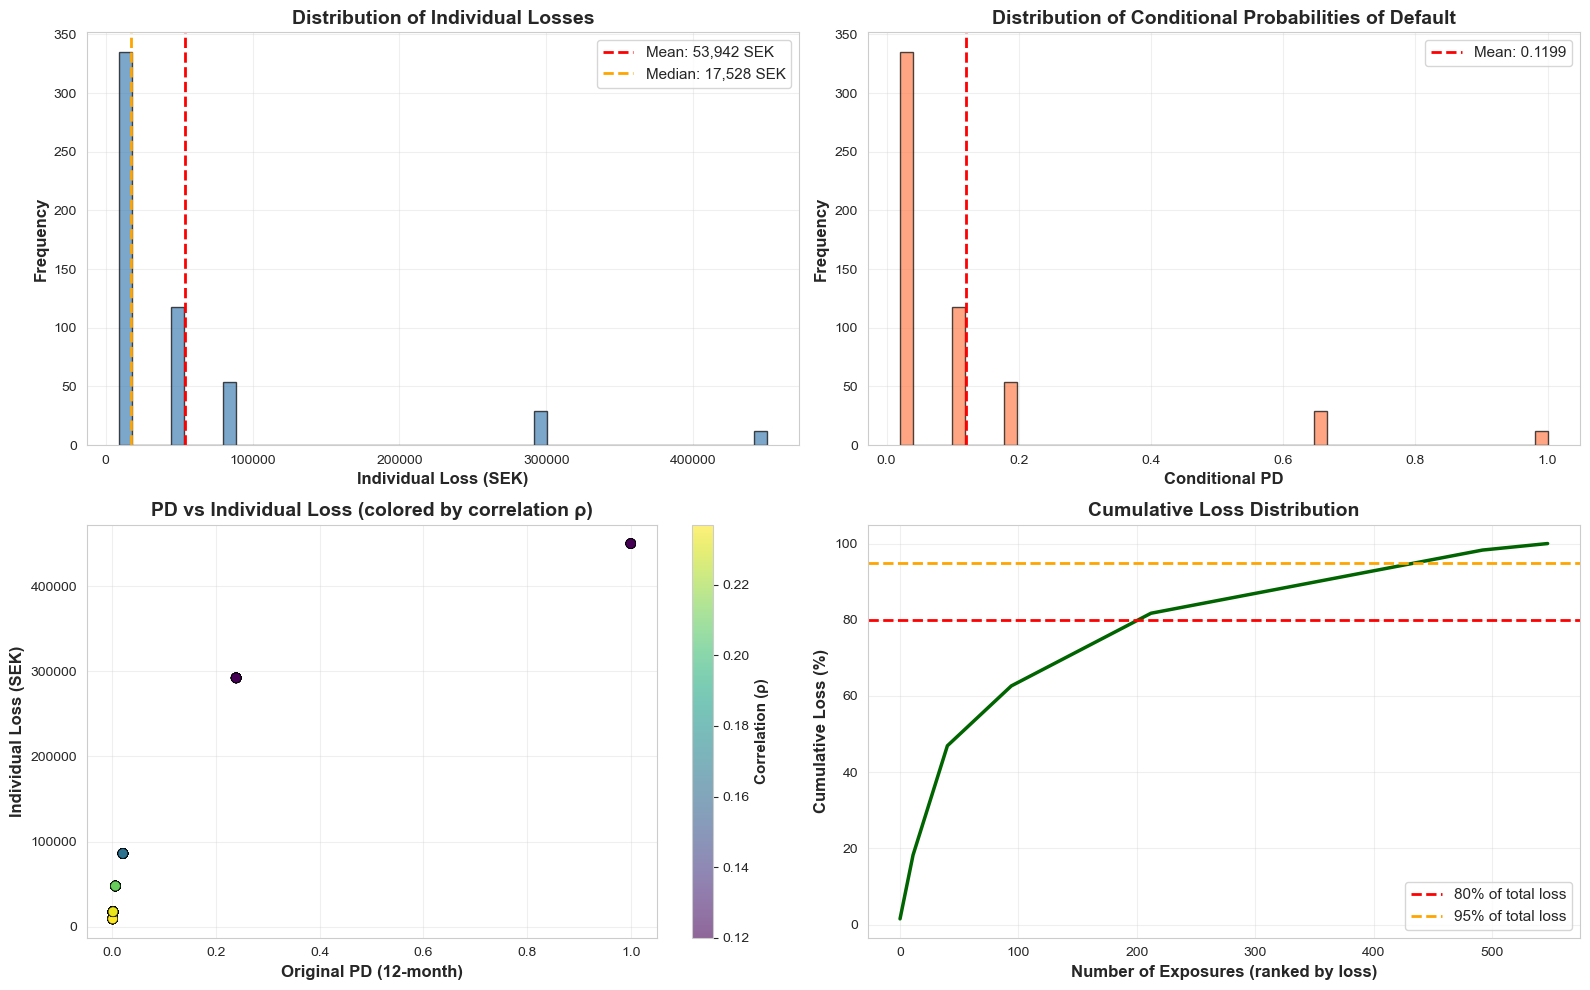


PORTFOLIO LOSS SUMMARY - HIGH LEVEL
Total Portfolio Loss:               29,560,372.61 SEK
Number of Exposures:                          548
Mean Loss per Exposure:                 53,942.29 SEK
Median Loss per Exposure:               17,528.49 SEK
Max Loss (single exposure):            450,000.00 SEK
Min Loss (single exposure):              9,198.93 SEK
Std Dev of Losses:                      86,270.16 SEK

CONCENTRATION ANALYSIS:
Top 10 exposures account for:                  15.22% of total loss
Top 50 exposures account for:                  49.56% of total loss
Top 100 exposures account for:                 63.45% of total loss

PD AND CORRELATION STATISTICS:
Mean PD:                                   0.0384
Median PD:                                 0.0012
Mean Correlation (ρ):                      0.2131
Median Correlation (ρ):                    0.2330
Mean Conditional PD:                       0.1199
Median Conditional PD:                     0.0390


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Create high-level visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Get the results dataframe
df_results = results['results_df']

# 1. Distribution of Individual Losses
ax1 = axes[0, 0]
ax1.hist(df_results['individual_loss'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(results['mean_loss'], color='red', linestyle='--', linewidth=2, label=f"Mean: {results['mean_loss']:,.0f} SEK")
ax1.axvline(results['median_loss'], color='orange', linestyle='--', linewidth=2, label=f"Median: {results['median_loss']:,.0f} SEK")
ax1.set_xlabel('Individual Loss (SEK)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Individual Losses', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 2. Distribution of Conditional PDs
ax2 = axes[0, 1]
ax2.hist(df_results['conditional_pd'], bins=50, color='coral', edgecolor='black', alpha=0.7)
ax2.axvline(df_results['conditional_pd'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f"Mean: {df_results['conditional_pd'].mean():.4f}")
ax2.set_xlabel('Conditional PD', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Conditional Probabilities of Default', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# 3. PD vs Individual Loss (scatter)
ax3 = axes[1, 0]
scatter = ax3.scatter(df_results['12_month'], df_results['individual_loss'], 
                     c=df_results['12_month_correlation'], cmap='viridis', 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax3.set_xlabel('Original PD (12-month)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Individual Loss (SEK)', fontsize=12, fontweight='bold')
ax3.set_title('PD vs Individual Loss (colored by correlation ρ)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Correlation (ρ)', fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Cumulative Loss Distribution
ax4 = axes[1, 1]
sorted_losses = df_results['individual_loss'].sort_values(ascending=False).reset_index(drop=True)
cumulative_loss = sorted_losses.cumsum()
cumulative_pct = (cumulative_loss / cumulative_loss.iloc[-1]) * 100
ax4.plot(range(len(cumulative_pct)), cumulative_pct, linewidth=2.5, color='darkgreen')
ax4.axhline(80, color='red', linestyle='--', linewidth=2, label='80% of total loss')
ax4.axhline(95, color='orange', linestyle='--', linewidth=2, label='95% of total loss')
ax4.set_xlabel('Number of Exposures (ranked by loss)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Cumulative Loss (%)', fontsize=12, fontweight='bold')
ax4.set_title('Cumulative Loss Distribution', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print high-level summary
print("\n" + "="*70)
print("PORTFOLIO LOSS SUMMARY - HIGH LEVEL")
print("="*70)
print(f"Total Portfolio Loss:        {results['total_loss']:>20,.2f} SEK")
print(f"Number of Exposures:         {len(df_results):>20,}")
print(f"Mean Loss per Exposure:      {results['mean_loss']:>20,.2f} SEK")
print(f"Median Loss per Exposure:    {results['median_loss']:>20,.2f} SEK")
print(f"Max Loss (single exposure):  {results['max_loss']:>20,.2f} SEK")
print(f"Min Loss (single exposure):  {df_results['individual_loss'].min():>20,.2f} SEK")
print(f"Std Dev of Losses:           {df_results['individual_loss'].std():>20,.2f} SEK")
print("="*70)

# Concentration analysis
sorted_losses_desc = df_results['individual_loss'].sort_values(ascending=False)
top_10_pct = (sorted_losses_desc.head(10).sum() / results['total_loss']) * 100
top_50_pct = (sorted_losses_desc.head(50).sum() / results['total_loss']) * 100
top_100_pct = (sorted_losses_desc.head(100).sum() / results['total_loss']) * 100

print("\nCONCENTRATION ANALYSIS:")
print("="*70)
print(f"Top 10 exposures account for:   {top_10_pct:>20.2f}% of total loss")
print(f"Top 50 exposures account for:   {top_50_pct:>20.2f}% of total loss")
print(f"Top 100 exposures account for:  {top_100_pct:>20.2f}% of total loss")
print("="*70)

# PD and Correlation statistics
print("\nPD AND CORRELATION STATISTICS:")
print("="*70)
print(f"Mean PD:                     {df_results['12_month'].mean():>20.4f}")
print(f"Median PD:                   {df_results['12_month'].median():>20.4f}")
print(f"Mean Correlation (ρ):        {df_results['12_month_correlation'].mean():>20.4f}")
print(f"Median Correlation (ρ):      {df_results['12_month_correlation'].median():>20.4f}")
print(f"Mean Conditional PD:         {df_results['conditional_pd'].mean():>20.4f}")
print(f"Median Conditional PD:       {df_results['conditional_pd'].median():>20.4f}")
print("="*70)

In [72]:
import numpy as np
from scipy.stats import norm

# ============================================================================
# HARDCODED PARAMETERS - Edit these values as needed
# ============================================================================
RWA_0 = 540_000_000   # Initial RWA (SEK) - Edit this value
CET1_0 = RWA_0 * 0.18  # Initial CET1 capital (SEK) - Edit this value 18% cet1 ratio to start

# ============================================================================

def calculate_maturity_adjustment(pd):
    return (0.11852 - 0.05478 * np.log(pd))**2


def calculate_capital_requirement(pd, lgd, correlation, maturity=2.5):
   
    # Ensure inputs are numpy arrays for vectorized operations
    pd = np.asarray(pd)
    lgd = np.asarray(lgd)
    correlation = np.asarray(correlation)
    
    # Calculate maturity adjustment factor
    b = calculate_maturity_adjustment(pd)
    
    # G(PD) - inverse normal of PD (quantile function)
    g_pd = norm.ppf(pd)
    
    # G(0.999) - inverse normal of 99.9% (quantile function)
    g_999 = norm.ppf(0.999)
    
    # Calculate the conditional PD term
    # [G(PD)/√(1-R) + √(R/(1-R)) · G(0.999)]
    conditional_pd_term = (g_pd / np.sqrt(1 - correlation) + 
                           np.sqrt(correlation / (1 - correlation)) * g_999)
    
    # N[...] - apply normal CDF
    n_term = norm.cdf(conditional_pd_term)
    
    # Calculate the base capital charge
    # [LGD · N[...] - PD · LGD]
    base_capital = lgd * n_term - pd * lgd
    
    # Calculate the maturity adjustment multiplier
    # [(1+(M-2.5)·b)/(1-1.5·b)]
    maturity_adjustment = (1 + (maturity - 2.5) * b) / (1 - 1.5 * b)
    
    # Final capital requirement
    K = base_capital * maturity_adjustment
    
    return K


def calculate_rwa(pd, lgd, ead, correlation, maturity=2.5):
    # Calculate capital requirement
    K = calculate_capital_requirement(pd, lgd, correlation, maturity)
    
    # Calculate RWA
    # The factor 12.5 comes from 1/8% (minimum capital ratio)
    RWA = K * 12.5 * ead
    
    return RWA


def calculate_risk_weight(pd, lgd, correlation, maturity=2.5):
   
    # Calculate capital requirement
    K = calculate_capital_requirement(pd, lgd, correlation, maturity)
    
    # Calculate Risk Weight
    RW = K * 12.5
    
    return RW


# Example usage and test
print("=" * 70)
print("BASEL II/III CAPITAL REQUIREMENT AND RWA CALCULATION FUNCTIONS")
print("=" * 70)
print("\nExample calculation with:")
print("  PD = 1% (0.01)")
print("  LGD = 45% (0.45)")
print("  EAD = 1,000,000 SEK")
print("  Correlation = 0.24 (Basel formula for corporate)")
print("  Maturity = 2.5 years (hardcoded)")
print()

# Test parameters
test_pd = 0.01
test_lgd = 0.45
test_ead = 1_000_000
test_correlation = 0.24
test_maturity = 2.5

# Calculate
K = calculate_capital_requirement(test_pd, test_lgd, test_correlation, test_maturity)
RW = calculate_risk_weight(test_pd, test_lgd, test_correlation, test_maturity)
RWA = calculate_rwa(test_pd, test_lgd, test_ead, test_correlation, test_maturity)

print(f"Results:")
print(f"  Capital Requirement (K): {K:.4f} ({K*100:.2f}%)")
print(f"  Risk Weight (RW):        {RW:.4f} ({RW*100:.2f}%)")
print(f"  Risk-Weighted Assets:    {RWA:,.2f} SEK")
print(f"  Minimum Capital (8%):    {RWA * 0.08:,.2f} SEK")
print("=" * 70)

BASEL II/III CAPITAL REQUIREMENT AND RWA CALCULATION FUNCTIONS

Example calculation with:
  PD = 1% (0.01)
  LGD = 45% (0.45)
  EAD = 1,000,000 SEK
  Correlation = 0.24 (Basel formula for corporate)
  Maturity = 2.5 years (hardcoded)

Results:
  Capital Requirement (K): 0.0939 (9.39%)
  Risk Weight (RW):        1.1741 (117.41%)
  Risk-Weighted Assets:    1,174,099.96 SEK
  Minimum Capital (8%):    93,928.00 SEK


In [68]:
# Calculate RWA for the entire portfolio
print("=" * 70)
print("CALCULATING RWA FOR ENTIRE PORTFOLIO")
print("=" * 70)

# Load the data with Basel correlations
df_portfolio = pd.read_csv('pdsFitchData_latest_with_basel_correlation.csv')

print(f"\nDataset loaded: {len(df_portfolio)} exposures")
print(f"Columns: {list(df_portfolio.columns)}")

# Parameters (consistent with previous analysis)
LGD = 0.45  # Loss Given Default: 45%
EAD = 1_000_000  # Exposure at Default: 1M SEK per exposure
MATURITY = 2.5  # Maturity: 2.5 years (hardcoded)

print(f"\nPortfolio parameters:")
print(f"  LGD: {LGD:.2%}")
print(f"  EAD per exposure: {EAD:,.0f} SEK")
print(f"  Maturity: {MATURITY} years")
print(f"  Total Portfolio EAD: {EAD * len(df_portfolio):,.0f} SEK")

# Calculate RWA for each tenor available
tenors = ['12_month', '24_month', '36_month', '60_month']
results_by_tenor = {}

for tenor in tenors:
    pd_col = tenor
    corr_col = f'{tenor}_correlation'
    
    # Check if columns exist and have data
    if pd_col in df_portfolio.columns and corr_col in df_portfolio.columns:
        # Filter rows with valid PD and correlation for this tenor
        mask = df_portfolio[pd_col].notna() & df_portfolio[corr_col].notna()
        df_valid = df_portfolio[mask].copy()
        
        if len(df_valid) > 0:
            # Calculate RWA for each exposure
            df_valid['K'] = calculate_capital_requirement(
                pd=df_valid[pd_col].values,
                lgd=LGD,
                correlation=df_valid[corr_col].values,
                maturity=MATURITY
            )
            
            df_valid['RW'] = calculate_risk_weight(
                pd=df_valid[pd_col].values,
                lgd=LGD,
                correlation=df_valid[corr_col].values,
                maturity=MATURITY
            )
            
            df_valid['RWA'] = calculate_rwa(
                pd=df_valid[pd_col].values,
                lgd=LGD,
                ead=EAD,
                correlation=df_valid[corr_col].values,
                maturity=MATURITY
            )
            
            # Store results
            results_by_tenor[tenor] = {
                'df': df_valid,
                'count': len(df_valid),
                'total_rwa': df_valid['RWA'].sum(),
                'total_ead': EAD * len(df_valid),
                'avg_rw': df_valid['RW'].mean(),
                'median_rw': df_valid['RW'].median(),
                'min_rwa': df_valid['RWA'].min(),
                'max_rwa': df_valid['RWA'].max(),
                'avg_pd': df_valid[pd_col].mean(),
                'median_pd': df_valid[pd_col].median()
            }

print("\n" + "=" * 70)
print("RWA RESULTS BY TENOR")
print("=" * 70)

for tenor, results in results_by_tenor.items():
    print(f"\n{tenor.upper().replace('_', ' ')}:")
    print(f"  Number of exposures: {results['count']:,}")
    print(f"  Total EAD: {results['total_ead']:,.0f} SEK")
    print(f"  Total RWA: {results['total_rwa']:,.0f} SEK")
    print(f"  Average Risk Weight: {results['avg_rw']:.2%}")
    print(f"  Median Risk Weight: {results['median_rw']:.2%}")
    print(f"  Min RWA per exposure: {results['min_rwa']:,.0f} SEK")
    print(f"  Max RWA per exposure: {results['max_rwa']:,.0f} SEK")
    print(f"  Average PD: {results['avg_pd']:.4f} ({results['avg_pd']*100:.2f}%)")
    print(f"  Median PD: {results['median_pd']:.4f} ({results['median_pd']*100:.2f}%)")
    print(f"  Capital Requirement (8% of RWA): {results['total_rwa'] * 0.08:,.0f} SEK")

# Focus on 12-month tenor for detailed analysis
if '12_month' in results_by_tenor:
    print("\n" + "=" * 70)
    print("DETAILED ANALYSIS - 12 MONTH TENOR")
    print("=" * 70)
    
    df_12m = results_by_tenor['12_month']['df']
    
    # Sort by RWA
    df_12m_sorted = df_12m.sort_values('RWA', ascending=False)
    
    print(f"\nTop 10 Exposures by RWA:")
    print()
    display_cols = ['Company_number', 'Sector', '12_month', '12_month_correlation', 'K', 'RW', 'RWA']
    print(df_12m_sorted[display_cols].head(10).to_string(index=False))
    
    print(f"\n\nBottom 10 Exposures by RWA:")
    print()
    print(df_12m_sorted[display_cols].tail(10).to_string(index=False))
    
    # Analysis by sector
    print("\n" + "=" * 70)
    print("RWA BY SECTOR (12 MONTH TENOR)")
    print("=" * 70)
    
    sector_analysis = df_12m.groupby('Sector').agg({
        'Company_number': 'count',
        '12_month': ['mean', 'median'],
        'RW': ['mean', 'median'],
        'RWA': ['sum', 'mean'],
        'K': 'mean'
    }).round(4)
    
    sector_analysis.columns = ['Count', 'Avg_PD', 'Med_PD', 'Avg_RW', 'Med_RW', 'Total_RWA', 'Avg_RWA', 'Avg_K']
    sector_analysis = sector_analysis.sort_values('Total_RWA', ascending=False)
    
    print()
    print(sector_analysis.to_string())
    
    print("\n" + "=" * 70)
    print("PORTFOLIO SUMMARY (12 MONTH TENOR)")
    print("=" * 70)
    
    total_rwa = results_by_tenor['12_month']['total_rwa']
    total_ead = results_by_tenor['12_month']['total_ead']
    avg_rw = results_by_tenor['12_month']['avg_rw']
    
    print(f"\nTotal Portfolio EAD: {total_ead:,.0f} SEK")
    print(f"Total Portfolio RWA: {total_rwa:,.0f} SEK")
    print(f"Overall Risk Weight: {(total_rwa/total_ead):.2%}")
    print(f"Average Risk Weight: {avg_rw:.2%}")
    print(f"Minimum Capital Required (8%): {total_rwa * 0.08:,.0f} SEK")
    print(f"Minimum Capital as % of EAD: {(total_rwa * 0.08 / total_ead):.2%}")
    print("=" * 70)

CALCULATING RWA FOR ENTIRE PORTFOLIO

Dataset loaded: 548 exposures
Columns: ['Company_number', 'Date', '1_month', '3_month', '6_month', '12_month', '24_month', '36_month', '60_month', 'Sector', '1_month_correlation', '3_month_correlation', '6_month_correlation', '12_month_correlation', '24_month_correlation', '36_month_correlation', '60_month_correlation']

Portfolio parameters:
  LGD: 45.00%
  EAD per exposure: 1,000,000 SEK
  Maturity: 2.5 years
  Total Portfolio EAD: 548,000,000 SEK

RWA RESULTS BY TENOR

12 MONTH:
  Number of exposures: 548
  Total EAD: 548,000,000 SEK
  Total RWA: 324,033,048 SEK
  Average Risk Weight: 59.13%
  Median Risk Weight: 32.96%
  Min RWA per exposure: 0 SEK
  Max RWA per exposure: 2,453,112 SEK
  Average PD: 0.0384 (3.84%)
  Median PD: 0.0012 (0.12%)
  Capital Requirement (8% of RWA): 25,922,644 SEK

DETAILED ANALYSIS - 12 MONTH TENOR

Top 10 Exposures by RWA:

 Company_number                             Sector  12_month  12_month_correlation        K  

In [74]:
# ============================================================================
# CET1 RATIO CALCULATIONS
# ============================================================================
print("=" * 70)
print("CET1 RATIO ANALYSIS")
print("=" * 70)

# Calculate portfolio loss using the calculate_portfolio_loss function
print("\nCalculating portfolio loss...")
portfolio_loss_results = calculate_portfolio_loss(tenor='12_month')
portfolio_loss_12m = portfolio_loss_results['total_loss']

print(f"\nInput Parameters:")
print(f"  Initial CET1 Capital (CET1_0): {CET1_0:,.0f} SEK")
print(f"  Initial RWA (RWA_0): {RWA_0:,.0f} SEK")
print(f"  Total Portfolio Loss (stressed): {portfolio_loss_12m:,.2f} SEK")

# Get RWA from the portfolio calculation (12-month tenor)
if '12_month' in results_by_tenor:
    total_rwa_12m = results_by_tenor['12_month']['total_rwa']
    total_ead_12m = results_by_tenor['12_month']['total_ead']
    
    print(f"\nPortfolio Metrics (12-month tenor):")
    print(f"  Total EAD: {total_ead_12m:,.0f} SEK")
    print(f"  Total RWA: {total_rwa_12m:,.0f} SEK")
    
    # Calculate new CET1 and RWA
    # The change in CET1 equals the total portfolio loss (as requested)
    new_cet1 = CET1_0 - portfolio_loss_12m
    new_rwa = RWA_0 + total_rwa_12m
    
    print(f"\n" + "=" * 70)
    print("INITIAL STATE")
    print("=" * 70)
    
    if CET1_0 > 0 and RWA_0 > 0:
        initial_cet1_ratio = (CET1_0 / RWA_0) * 100
        print(f"  Initial CET1 Capital: {CET1_0:,.0f} SEK")
        print(f"  Initial RWA: {RWA_0:,.0f} SEK")
        print(f"  Initial CET1 Ratio: {initial_cet1_ratio:.2f}%")
    else:
        print(f"  Initial CET1 Capital: {CET1_0:,.0f} SEK")
        print(f"  Initial RWA: {RWA_0:,.0f} SEK")
        print(f"  Initial CET1 Ratio: N/A (CET1_0 or RWA_0 is zero)")
    
    print(f"\n" + "=" * 70)
    print("IMPACT OF PORTFOLIO")
    print("=" * 70)
    print(f"  Portfolio Loss (impact on CET1): -{portfolio_loss_12m:,.2f} SEK")
    print(f"  Additional RWA from portfolio: +{total_rwa_12m:,.0f} SEK")
    
    print(f"\n" + "=" * 70)
    print("NEW STATE (AFTER PORTFOLIO IMPACT)")
    print("=" * 70)
    print(f"  New CET1 Capital: {new_cet1:,.2f} SEK")
    print(f"  New RWA: {new_rwa:,.0f} SEK")
    
    if new_rwa > 0:
        new_cet1_ratio = (new_cet1 / new_rwa) * 100
        print(f"  New CET1 Ratio: {new_cet1_ratio:.2f}%")
        
        print(f"\n" + "=" * 70)
        print("REGULATORY CAPITAL REQUIREMENTS")
        print("=" * 70)
        
        # Basel III minimum requirements
        minimum_cet1_ratio = 4.5  # %
        capital_conservation_buffer = 2.5  # %
        total_minimum_ratio = minimum_cet1_ratio + capital_conservation_buffer  # 7.0%
        
        minimum_cet1_required = new_rwa * (minimum_cet1_ratio / 100)
        total_cet1_required = new_rwa * (total_minimum_ratio / 100)
        
        print(f"  Minimum CET1 Ratio (Basel III): {minimum_cet1_ratio}%")
        print(f"  Minimum CET1 Capital Required: {minimum_cet1_required:,.0f} SEK")
        print(f"\n  CET1 Ratio with Buffers: {total_minimum_ratio}%")
        print(f"  CET1 Capital Required (with buffers): {total_cet1_required:,.0f} SEK")
        
        print(f"\n" + "=" * 70)
        print("CAPITAL ADEQUACY ASSESSMENT")
        print("=" * 70)
        
        surplus_deficit_minimum = new_cet1 - minimum_cet1_required
        surplus_deficit_buffers = new_cet1 - total_cet1_required
        
        print(f"  Surplus/(Deficit) vs. Minimum: {surplus_deficit_minimum:,.2f} SEK")
        print(f"  Surplus/(Deficit) vs. Buffers: {surplus_deficit_buffers:,.2f} SEK")
        
        if new_cet1_ratio >= total_minimum_ratio:
            print(f"\n  ✓ ADEQUATE: CET1 ratio ({new_cet1_ratio:.2f}%) meets requirements")
        elif new_cet1_ratio >= minimum_cet1_ratio:
            print(f"\n  ⚠ WARNING: CET1 ratio ({new_cet1_ratio:.2f}%) meets minimum but not buffers")
        else:
            print(f"\n  ✗ INADEQUATE: CET1 ratio ({new_cet1_ratio:.2f}%) below minimum requirement")
        
        # Calculate change in CET1 ratio
        if CET1_0 > 0 and RWA_0 > 0:
            change_in_ratio = new_cet1_ratio - initial_cet1_ratio
            print(f"\n  Change in CET1 Ratio: {change_in_ratio:+.2f} percentage points")
    else:
        print(f"  New CET1 Ratio: N/A (RWA is zero)")
    
    print("=" * 70)
    
    # Store results for potential further analysis
    cet1_results = {
        'initial_cet1': CET1_0,
        'initial_rwa': RWA_0,
        'portfolio_loss': portfolio_loss_12m,
        'portfolio_rwa': total_rwa_12m,
        'new_cet1': new_cet1,
        'new_rwa': new_rwa,
        'new_cet1_ratio': (new_cet1 / new_rwa * 100) if new_rwa > 0 else None
    }
    
    # Print CET1 results dictionary
    print("\n" + "=" * 70)
    print("CET1 RESULTS DICTIONARY")
    print("=" * 70)
    for key, value in cet1_results.items():
        if value is not None and isinstance(value, (int, float)):
            if 'ratio' in key:
                print(f"  {key}: {value:.2f}%")
            else:
                print(f"  {key}: {value:,.2f} SEK")
        else:
            print(f"  {key}: {value}")
    print("=" * 70)
else:
    print("\nError: 12-month tenor results not found. Please run the RWA calculation cell first.")
    cet1_results = None

CET1 RATIO ANALYSIS

Calculating portfolio loss...
Calculating portfolio loss for 12_month tenor
Number of valid exposures: 548

Hardcoded parameters:
  q (quantile):        0.999
  EAD (exposure):      1,000,000 SEK
  LGD (loss given df): 45.00%

PD range: 0.0005 to 1.0000
ρ range:  0.1200 to 0.2370

RESULTS:
Total Portfolio Loss:    29,560,372.61 SEK
Mean Individual Loss:    53,942.29 SEK
Median Individual Loss:  17,528.49 SEK
Max Individual Loss:     450,000.00 SEK

Input Parameters:
  Initial CET1 Capital (CET1_0): 97,200,000 SEK
  Initial RWA (RWA_0): 540,000,000 SEK
  Total Portfolio Loss (stressed): 29,560,372.61 SEK

Portfolio Metrics (12-month tenor):
  Total EAD: 548,000,000 SEK
  Total RWA: 324,033,048 SEK

INITIAL STATE
  Initial CET1 Capital: 97,200,000 SEK
  Initial RWA: 540,000,000 SEK
  Initial CET1 Ratio: 18.00%

IMPACT OF PORTFOLIO
  Portfolio Loss (impact on CET1): -29,560,372.61 SEK
  Additional RWA from portfolio: +324,033,048 SEK

NEW STATE (AFTER PORTFOLIO IMPACT